# Federated Learning for Cross-Bank Fraud Detection
## IEEE-CIS Fraud Detection Dataset — Full Benchmark

**Framework:** FedAvg · FedProx · FedNova · PersFL (MLP backbone) + XGBoost / LightGBM local experts  
**Partitions:** Dirichlet α ∈ {0.5, 0.1, 0.05} · N=4 simulated banks · 20 FL rounds  
**Metrics:** AUPRC · AUC-ROC · F1 · F2 · MCC · G-Mean · Balanced Accuracy · AP@K · Typology Coverage · Typology-Weighted F1 · Client Equity · Worst-Bank F1 · Collaboration Gain · Typology JSD

## 0 — Imports & Configuration

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings, copy, json, itertools, time
from pathlib import Path
from collections import defaultdict

# ── Numerical / ML ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy.stats import dirichlet
from scipy.spatial.distance import jensenshannon

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, matthews_corrcoef,
    confusion_matrix, balanced_accuracy_score,
    fbeta_score
)
from sklearn.impute import SimpleImputer

import xgboost as xgb
import lightgbm as lgb

# ── Plotting ──────────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Experiment Configuration ───────────────────────────────────────────────────
CFG = dict(
    data_dir        = Path('../../Academics/UTS/Autumn Session 2026/49275 Neural Network and Fuzzy Logic/datasets/ieee-fraud-detection')           ,  # <-- SET to folder containing train_transaction.csv
    n_banks         = 4                   ,
    fl_rounds       = 20                  ,
    local_epochs    = 3                   ,
    batch_size      = 512                 ,
    lr              = 1e-3                ,
    mu_fedprox      = 0.01                ,  # FedProx proximal term
    alphas          = [0.5, 0.1, 0.05]   ,  # Dirichlet concentrations
    min_fraud_per_bank = 30               ,  # guaranteed minimum fraud samples
    k_values        = [50, 100, 200]      ,  # for AP@K
    device          = 'cuda' if torch.cuda.is_available() else 'cpu',
    hidden_dims     = [256, 128, 64]      ,
    dropout         = 0.3                 ,
)

# Fraud typology classes (17 simulated typology labels)
TYPOLOGY_NAMES = [
    'card_not_present', 'account_takeover', 'synthetic_identity',
    'first_party_fraud', 'money_mule', 'cross_border_high_value',
    'structuring', 'rapid_movement', 'new_account_fraud',
    'friendly_fraud', 'bust_out', 'triangulation',
    'refund_abuse', 'merchant_collusion', 'cross_border_high_risk',
    'high_risk_country', 'layering'
]

# Severity weights for Typology-Weighted F1 (cross-border + high-risk → higher weight)
TYPOLOGY_WEIGHTS = {
    t: (3.0 if 'cross_border' in t or 'high_risk' in t or t in ('layering','structuring','money_mule')
        else 2.0 if t in ('account_takeover','synthetic_identity','bust_out','merchant_collusion')
        else 1.0)
    for t in TYPOLOGY_NAMES
}

ALPHA_LABELS = {0.5: 'Moderate (α=0.5)', 0.1: 'Extreme (α=0.1)', 0.05: 'Very Extreme (α=0.05)'}
FL_ALGOS     = ['FedAvg', 'FedProx', 'FedNova', 'PersFL']
TREE_MODELS  = ['XGBoost', 'LightGBM']
ALL_MODELS   = FL_ALGOS + TREE_MODELS

PALETTE = {
    'FedAvg'  : '#4C72B0', 'FedProx': '#DD8452',
    'FedNova' : '#55A868', 'PersFL' : '#C44E52',
    'XGBoost' : '#8172B2', 'LightGBM':'#937860',
}

print(f"Device: {CFG['device']}")
print(f"FL Rounds: {CFG['fl_rounds']} | Banks: {CFG['n_banks']} | Alphas: {CFG['alphas']}")

Device: cpu
FL Rounds: 20 | Banks: 4 | Alphas: [0.5, 0.1, 0.05]


## 1 — Data Loading & Preprocessing

In [2]:
def load_ieee_cis(data_dir: Path) -> pd.DataFrame:
    """Load and merge IEEE-CIS transaction + identity tables."""
    trans_path = data_dir / 'train_transaction.csv'
    ident_path = data_dir / 'train_identity.csv'

    print('Loading transaction data...')
    df_trans = pd.read_csv(trans_path)

    if ident_path.exists():
        print('Loading identity data...')
        df_ident = pd.read_csv(ident_path)
        df = df_trans.merge(df_ident, on='TransactionID', how='left')
    else:
        print('Identity file not found — using transactions only.')
        df = df_trans

    print(f'Shape: {df.shape}  |  Fraud rate: {df["isFraud"].mean():.4%}')
    return df


def preprocess(df: pd.DataFrame):
    """Feature engineering + encoding + scaling."""
    df = df.copy()

    # Drop columns with > 80 % missing
    thresh = 0.8 * len(df)
    df = df.dropna(axis=1, thresh=int(len(df) - thresh))

    y = df['isFraud'].values.astype(np.float32)
    X = df.drop(columns=['isFraud', 'TransactionID'], errors='ignore')

    # Encode categoricals
    cat_cols = X.select_dtypes(include='object').columns
    le = LabelEncoder()
    for c in cat_cols:
        X[c] = X[c].astype(str)
        X[c] = le.fit_transform(X[c])

    # Impute
    imp = SimpleImputer(strategy='median')
    X_arr = imp.fit_transform(X).astype(np.float32)

    # Scale
    scaler = StandardScaler()
    X_arr = scaler.fit_transform(X_arr).astype(np.float32)

    print(f'Features after preprocessing: {X_arr.shape[1]}')
    return X_arr, y, list(X.columns)


def assign_typologies(y: np.ndarray, n_typologies: int = 17, seed: int = 42) -> np.ndarray:
    """Assign simulated typology labels to fraud samples."""
    rng = np.random.RandomState(seed)
    fraud_idx = np.where(y == 1)[0]
    typology_arr = np.full(len(y), -1, dtype=int)  # -1 = legitimate
    # Draw from categorical with slight bias toward first few typologies
    probs = np.array([max(0.02, 1/(i+1)) for i in range(n_typologies)])
    probs /= probs.sum()
    typology_arr[fraud_idx] = rng.choice(n_typologies, size=len(fraud_idx), p=probs)
    return typology_arr


# ── Load data ─────────────────────────────────────────────────────────────────
df_raw = load_ieee_cis(CFG['data_dir'])
X_all, y_all, feature_names = preprocess(df_raw)
typology_all = assign_typologies(y_all, n_typologies=len(TYPOLOGY_NAMES))

# Global train / test split (stratified)
X_train_g, X_test_g, y_train_g, y_test_g, typo_train_g, typo_test_g = train_test_split(
    X_all, y_all, typology_all,
    test_size=0.2, random_state=SEED, stratify=y_all
)

N_FEATURES = X_train_g.shape[1]
print(f'Train: {X_train_g.shape} | Test: {X_test_g.shape}')
print(f'Train fraud: {y_train_g.mean():.4%} | Test fraud: {y_test_g.mean():.4%}')

Loading transaction data...
Loading identity data...
Shape: (590540, 434)  |  Fraud rate: 3.4990%
Features after preprocessing: 358
Train: (472432, 358) | Test: (118108, 358)
Train fraud: 3.4989% | Test fraud: 3.4993%


## 2 — Dirichlet Partitioning (Cross-Bank Simulation)

In [3]:
def dirichlet_partition(
    X: np.ndarray, y: np.ndarray, typo: np.ndarray,
    n_clients: int, alpha: float,
    min_fraud: int = 30, seed: int = 42
):
    """
    Dirichlet-based non-IID partition with guaranteed minimum fraud per bank.
    Returns list of (X_c, y_c, typo_c) per client.
    """
    rng = np.random.RandomState(seed)
    fraud_idx  = np.where(y == 1)[0]
    legit_idx  = np.where(y == 0)[0]

    # --- Guarantee minimum fraud per bank ---
    rng.shuffle(fraud_idx)
    guaranteed = [fraud_idx[i*min_fraud:(i+1)*min_fraud] for i in range(n_clients)]
    remaining_fraud = fraud_idx[n_clients*min_fraud:]

    # Dirichlet draw over remaining fraud
    props_fraud = rng.dirichlet(alpha * np.ones(n_clients))
    props_legit = rng.dirichlet(alpha * np.ones(n_clients))

    counts_fraud = (props_fraud * len(remaining_fraud)).astype(int)
    counts_fraud[-1] = len(remaining_fraud) - counts_fraud[:-1].sum()

    counts_legit = (props_legit * len(legit_idx)).astype(int)
    counts_legit[-1] = len(legit_idx) - counts_legit[:-1].sum()

    rng.shuffle(remaining_fraud)
    rng.shuffle(legit_idx)

    clients = []
    f_ptr, l_ptr = 0, 0
    for i in range(n_clients):
        f_end = f_ptr + counts_fraud[i]
        l_end = l_ptr + counts_legit[i]
        idx_f = np.concatenate([guaranteed[i], remaining_fraud[f_ptr:f_end]])
        idx_l = legit_idx[l_ptr:l_end]
        idx   = np.concatenate([idx_f, idx_l])
        rng.shuffle(idx)
        clients.append((X[idx], y[idx], typo[idx]))
        f_ptr = f_end
        l_ptr = l_end

    return clients


def compute_typology_jsd(clients):
    """Jensen-Shannon divergence of typology distributions across clients."""
    n_typo = len(TYPOLOGY_NAMES)
    distributions = []
    for _, y_c, typo_c in clients:
        fraud_mask = y_c == 1
        if fraud_mask.sum() == 0:
            distributions.append(np.ones(n_typo) / n_typo)
            continue
        counts = np.bincount(typo_c[fraud_mask], minlength=n_typo).astype(float)
        counts += 1e-8
        distributions.append(counts / counts.sum())

    # Mean pairwise JSD
    jsds = []
    for i, j in itertools.combinations(range(len(distributions)), 2):
        jsds.append(jensenshannon(distributions[i], distributions[j]))
    return float(np.mean(jsds)), distributions


# ── Preview partitions ────────────────────────────────────────────────────────
print('Partition statistics:\n')
print(f'{"Alpha":<10} {"Bank":<6} {"N":<8} {"Fraud":<10} {"Fraud%":<10} {"JSD":<8}')
print('-' * 56)

partition_cache = {}  # alpha → clients list
jsd_cache       = {}  # alpha → jsd scalar

for alpha in CFG['alphas']:
    clients = dirichlet_partition(
        X_train_g, y_train_g, typo_train_g,
        n_clients=CFG['n_banks'], alpha=alpha,
        min_fraud=CFG['min_fraud_per_bank'], seed=SEED
    )
    partition_cache[alpha] = clients
    jsd, _ = compute_typology_jsd(clients)
    jsd_cache[alpha] = jsd

    for b, (Xb, yb, _) in enumerate(clients):
        jsd_str = f'{jsd:.4f}' if b == 0 else ''
        print(f'{alpha:<10} {b:<6} {len(Xb):<8} {int(yb.sum()):<10} {yb.mean():<10.4%} {jsd_str}')
    print()

Partition statistics:

Alpha      Bank   N        Fraud      Fraud%     JSD     
--------------------------------------------------------
0.5        0      292052   6403       2.1924%    0.0413
0.5        1      2602     2529       97.1945%   
0.5        2      8329     7225       86.7451%   
0.5        3      169449   373        0.2201%    

0.1        0      49       49         100.0000%  0.1545
0.1        1      462167   6266       1.3558%    
0.1        2      99       99         100.0000%  
0.1        3      10117    10116      99.9901%   

0.05       0      30       30         100.0000%  0.2483
0.05       1      460469   4568       0.9920%    
0.05       2      30       30         100.0000%  
0.05       3      11903    11902      99.9916%   



## 3 — MLP Model & FL Utilities

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# 3.1  MLP Backbone
# ══════════════════════════════════════════════════════════════════════════════

class FraudMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: list, dropout: float = 0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


# ══════════════════════════════════════════════════════════════════════════════
# 3.2  Shared utilities
# ══════════════════════════════════════════════════════════════════════════════

def get_pos_weight(y: np.ndarray) -> torch.Tensor:
    n_neg = (y == 0).sum()
    n_pos = (y == 1).sum()
    return torch.tensor(n_neg / max(n_pos, 1), dtype=torch.float32)


def make_loader(X: np.ndarray, y: np.ndarray, batch_size: int, shuffle: bool = True):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)


def get_model_params(model: nn.Module) -> list:
    return [p.data.clone() for p in model.parameters()]


def set_model_params(model: nn.Module, params: list):
    with torch.no_grad():
        for p, new_p in zip(model.parameters(), params):
            p.data.copy_(new_p)


def model_predict_proba(model: nn.Module, X: np.ndarray, device: str) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        t = torch.from_numpy(X).to(device)
        logits = model(t)
        probs  = torch.sigmoid(logits).cpu().numpy()
    return probs


# ══════════════════════════════════════════════════════════════════════════════
# 3.3  Local training step (generic — used by all FL algos)
# ══════════════════════════════════════════════════════════════════════════════

def local_train(
    model: nn.Module,
    X: np.ndarray, y: np.ndarray,
    epochs: int, batch_size: int, lr: float,
    device: str,
    algo: str = 'FedAvg',
    mu: float = 0.01,
    global_params: list = None,
    rho: float = 0.9,        # FedNova momentum
):
    """
    Returns (updated_model, tau_eff) where tau_eff is the effective
    local update normaliser used by FedNova.
    """
    model.train().to(device)
    pos_w    = get_pos_weight(y).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loader    = make_loader(X, y, batch_size)

    tau = 0  # step counter for FedNova
    for _ in range(epochs):
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(Xb)
            loss   = criterion(logits, yb)

            # FedProx proximal term
            if algo == 'FedProx' and global_params is not None:
                prox = sum(
                    ((p - g.to(device)) ** 2).sum()
                    for p, g in zip(model.parameters(), global_params)
                )
                loss = loss + (mu / 2) * prox

            loss.backward()
            optimizer.step()
            tau += 1

    tau_eff = tau / (1 - rho ** tau + 1e-10)  # FedNova effective tau
    return model, tau_eff


# ══════════════════════════════════════════════════════════════════════════════
# 3.4  Aggregation strategies
# ══════════════════════════════════════════════════════════════════════════════

def fedavg_aggregate(global_params, local_params_list, weights):
    """Standard FedAvg weighted aggregation."""
    new_params = []
    total_w = sum(weights)
    for layer_idx in range(len(global_params)):
        agg = sum(
            (w / total_w) * lp[layer_idx]
            for w, lp in zip(weights, local_params_list)
        )
        new_params.append(agg)
    return new_params


def fednova_aggregate(global_params, local_params_list, weights, tau_effs):
    """FedNova: normalise by effective local steps before aggregation."""
    total_w  = sum(weights)
    tau_mean = sum(w * t for w, t in zip(weights, tau_effs)) / total_w
    new_params = []
    for layer_idx in range(len(global_params)):
        grad_sum = sum(
            (w / total_w) * (global_params[layer_idx] - lp[layer_idx]) / (tau + 1e-10)
            for w, lp, tau in zip(weights, local_params_list, tau_effs)
        )
        new_params.append(global_params[layer_idx] - tau_mean * grad_sum)
    return new_params


print('MLP and FL utilities defined.')

MLP and FL utilities defined.


## 4 — Metric Suite

In [5]:
def compute_threshold_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    sens = tp / max(tp + fn, 1)   # recall / sensitivity
    spec = tn / max(tn + fp, 1)   # specificity
    return dict(
        F1   = f1_score(y_true, y_pred, zero_division=0),
        F2   = fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        MCC  = matthews_corrcoef(y_true, y_pred),
        GMean= float(np.sqrt(sens * spec)),
        BalAcc = balanced_accuracy_score(y_true, y_pred),
    )


def compute_apk(y_true, y_prob, k):
    """Alert Precision at K: precision of top-K ranked predictions."""
    top_k = np.argsort(y_prob)[::-1][:k]
    return float(y_true[top_k].mean())


def compute_typology_metrics(y_true, y_pred, typo_labels):
    """Typology Coverage and Typology-Weighted F1."""
    n_typo = len(TYPOLOGY_NAMES)
    f1s, weights = [], []
    covered = 0
    fraud_mask = y_true == 1
    for i, name in enumerate(TYPOLOGY_NAMES):
        typo_mask = (typo_labels == i) & fraud_mask
        if typo_mask.sum() == 0:
            f1s.append(0.0)
        else:
            yt = (typo_labels == i).astype(int)
            f1_val = f1_score(yt, y_pred, zero_division=0)
            f1s.append(f1_val)
            if f1_val > 0:
                covered += 1
        weights.append(TYPOLOGY_WEIGHTS[name])

    weights = np.array(weights)
    f1s     = np.array(f1s)
    w_f1    = float((f1s * weights).sum() / weights.sum())
    return dict(
        TypologyCoverage = covered,
        TypologyWeightedF1 = w_f1,
        TypologyF1s = f1s.tolist(),
    )


def compute_full_metrics(
    y_true, y_prob, typo_labels,
    k_values, threshold=0.5
):
    """Compute all benchmark metrics."""
    m = {}
    # Threshold-independent
    m['AUPRC']   = float(average_precision_score(y_true, y_prob))
    m['AUC_ROC'] = float(roc_auc_score(y_true, y_prob))
    # Threshold-dependent
    m.update(compute_threshold_metrics(y_true, y_prob, threshold))
    # AP@K
    for k in k_values:
        m[f'AP@{k}'] = compute_apk(y_true, y_prob, k)
    # Typology
    y_pred = (y_prob >= threshold).astype(int)
    m.update(compute_typology_metrics(y_true, y_pred, typo_labels))
    return m


def compute_fl_fairness_metrics(per_bank_f1s, local_only_f1s):
    """FL-specific fairness: Client Equity, Worst-Bank F1, Collaboration Gain."""
    arr = np.array(per_bank_f1s)
    loc = np.array(local_only_f1s)
    return dict(
        ClientEquity     = float(np.std(arr)),
        WorstBankF1      = float(arr.min()),
        CollaborationGain= float((arr - loc).mean()),
        CollabGainPerBank= (arr - loc).tolist(),
    )


print('Metric suite defined.')

Metric suite defined.


## 5 — FL Algorithm Implementations

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# 5.1  Generic FL runner
# ══════════════════════════════════════════════════════════════════════════════

def run_fl(
    algo: str,
    clients,              # list of (X_c, y_c, typo_c)
    X_test, y_test, typo_test,
    cfg: dict,
) -> dict:
    """
    Run a FL algorithm for cfg['fl_rounds'] rounds.
    Returns dict with round-by-round AUPRC and final full metrics.
    """
    device = cfg['device']
    n_clients = len(clients)

    # Initialise global model
    global_model = FraudMLP(
        input_dim   = cfg['n_features'],
        hidden_dims = cfg['hidden_dims'],
        dropout     = cfg['dropout'],
    ).to(device)

    # PersFL: each client keeps its own personalised model
    if algo == 'PersFL':
        pers_models = [
            copy.deepcopy(global_model) for _ in range(n_clients)
        ]

    round_auprc   = []
    client_sizes  = [len(c[1]) for c in clients]

    for rnd in range(cfg['fl_rounds']):
        local_params_list = []
        tau_effs          = []
        global_params     = get_model_params(global_model)

        for i, (Xc, yc, _) in enumerate(clients):
            if algo == 'PersFL':
                # PersFL: start from personalised model, then fine-tune
                local_model = copy.deepcopy(pers_models[i])
                # Mix global and personal (Ditto-style, λ=0.5)
                local_params = get_model_params(local_model)
                mixed = [0.5 * g + 0.5 * l for g, l in zip(global_params, local_params)]
                set_model_params(local_model, mixed)
            else:
                local_model = copy.deepcopy(global_model)

            local_model, tau_eff = local_train(
                local_model, Xc, yc,
                epochs     = cfg['local_epochs'],
                batch_size = cfg['batch_size'],
                lr         = cfg['lr'],
                device     = device,
                algo       = algo,
                mu         = cfg['mu_fedprox'],
                global_params = global_params,
            )

            local_params_list.append(get_model_params(local_model))
            tau_effs.append(tau_eff)

            if algo == 'PersFL':
                pers_models[i] = local_model  # update personalised

        # Aggregate
        if algo == 'FedNova':
            new_global = fednova_aggregate(global_params, local_params_list,
                                           client_sizes, tau_effs)
        else:
            new_global = fedavg_aggregate(global_params, local_params_list, client_sizes)

        set_model_params(global_model, new_global)

        # Evaluate on test set
        if algo == 'PersFL':
            # Average personalised predictions
            probs_list = [
                model_predict_proba(pm, X_test, device)
                for pm in pers_models
            ]
            probs = np.mean(probs_list, axis=0)
        else:
            probs = model_predict_proba(global_model, X_test, device)

        auprc = average_precision_score(y_test, probs)
        round_auprc.append(auprc)

        if (rnd + 1) % 5 == 0:
            print(f'  [{algo}] Round {rnd+1:2d}/{cfg["fl_rounds"]} — AUPRC: {auprc:.4f}')

    # Final full metrics
    final_metrics = compute_full_metrics(
        y_test, probs, typo_test,
        k_values=cfg['k_values']
    )

    # Per-bank evaluation for fairness metrics
    per_bank_f1 = []
    for i, (Xc, yc, _) in enumerate(clients):
        if algo == 'PersFL':
            p = model_predict_proba(pers_models[i], Xc, device)
        else:
            p = model_predict_proba(global_model, Xc, device)
        yp = (p >= 0.5).astype(int)
        per_bank_f1.append(f1_score(yc, yp, zero_division=0))

    return dict(
        round_auprc  = round_auprc,
        final_metrics= final_metrics,
        per_bank_f1  = per_bank_f1,
        probs_test   = probs,
    )


# ══════════════════════════════════════════════════════════════════════════════
# 5.2  Local-only baseline (for Collaboration Gain)
# ══════════════════════════════════════════════════════════════════════════════

def run_local_only(clients, X_test, y_test, cfg):
    """Train each client independently; return per-bank F1 on test set."""
    device = cfg['device']
    per_bank_f1 = []
    for Xc, yc, _ in clients:
        model = FraudMLP(cfg['n_features'], cfg['hidden_dims'], cfg['dropout']).to(device)
        model, _ = local_train(
            model, Xc, yc,
            epochs=cfg['fl_rounds'] * cfg['local_epochs'],  # same compute budget
            batch_size=cfg['batch_size'], lr=cfg['lr'], device=device
        )
        p = model_predict_proba(model, X_test, device)
        per_bank_f1.append(f1_score(y_test, (p >= 0.5).astype(int), zero_division=0))
    return per_bank_f1


# ══════════════════════════════════════════════════════════════════════════════
# 5.3  Tree-based local experts
# ══════════════════════════════════════════════════════════════════════════════

def run_tree_model(name, X_train, y_train, X_test, y_test, typo_test, clients, cfg):
    """Train a single XGBoost or LightGBM on the full training set (centralised expert)."""
    sw = y_train.shape[0] / (2 * np.bincount(y_train.astype(int)))
    sample_weight = sw[y_train.astype(int)]

    if name == 'XGBoost':
        ratio = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
        model = xgb.XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            scale_pos_weight=ratio, subsample=0.8,
            colsample_bytree=0.8, random_state=SEED,
            eval_metric='aucpr', use_label_encoder=False,
            verbosity=0,
        )
    else:  # LightGBM
        model = lgb.LGBMClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            is_unbalance=True, subsample=0.8,
            colsample_bytree=0.8, random_state=SEED,
            verbose=-1,
        )

    model.fit(X_train, y_train, sample_weight=sample_weight)
    probs = model.predict_proba(X_test)[:, 1]
    final_metrics = compute_full_metrics(y_test, probs, typo_test, cfg['k_values'])

    # Per-bank (apply tree to each client's data — centralised model evaluated locally)
    per_bank_f1 = []
    for Xc, yc, _ in clients:
        p = model.predict_proba(Xc)[:, 1]
        per_bank_f1.append(f1_score(yc, (p >= 0.5).astype(int), zero_division=0))

    return dict(
        round_auprc   = None,
        final_metrics = final_metrics,
        per_bank_f1   = per_bank_f1,
        probs_test    = probs,
    )


print('FL algorithm implementations defined.')

FL algorithm implementations defined.


## 6 — Full Experiment Loop

In [7]:
cfg = dict(CFG)  # working copy
cfg['n_features'] = N_FEATURES

RESULTS = {}   # (alpha, model) → result dict
LOCAL_ONLY_F1 = {}  # alpha → per_bank_f1 list

for alpha in CFG['alphas']:
    clients = partition_cache[alpha]
    print(f'\n{"═"*60}')
    print(f'  Dirichlet α = {alpha}  ({ALPHA_LABELS[alpha]})')
    print(f'{"═"*60}')

    # Local-only baseline (for collaboration gain)
    print('  → Local-only baseline...')
    local_f1 = run_local_only(clients, X_test_g, y_test_g, cfg)
    LOCAL_ONLY_F1[alpha] = local_f1

    # FL algorithms (MLP backbone)
    for algo in FL_ALGOS:
        print(f'  → {algo}...')
        t0 = time.time()
        result = run_fl(
            algo, clients,
            X_test_g, y_test_g, typo_test_g,
            cfg
        )
        # Compute FL fairness metrics
        fairness = compute_fl_fairness_metrics(
            result['per_bank_f1'], LOCAL_ONLY_F1[alpha]
        )
        result['fairness']   = fairness
        result['jsd']        = jsd_cache[alpha]
        result['elapsed_s']  = time.time() - t0
        RESULTS[(alpha, algo)] = result
        fm = result['final_metrics']
        print(f'     AUPRC={fm["AUPRC"]:.4f}  F1={fm["F1"]:.4f}  '
              f'MCC={fm["MCC"]:.4f}  Collab={fairness["CollaborationGain"]:+.4f}')

    # Tree-based models
    for tree in TREE_MODELS:
        print(f'  → {tree}...')
        t0 = time.time()
        result = run_tree_model(
            tree, X_train_g, y_train_g,
            X_test_g, y_test_g, typo_test_g,
            clients, cfg
        )
        fairness = compute_fl_fairness_metrics(
            result['per_bank_f1'], LOCAL_ONLY_F1[alpha]
        )
        result['fairness']  = fairness
        result['jsd']       = jsd_cache[alpha]
        result['elapsed_s'] = time.time() - t0
        RESULTS[(alpha, tree)] = result
        fm = result['final_metrics']
        print(f'     AUPRC={fm["AUPRC"]:.4f}  F1={fm["F1"]:.4f}  '
              f'MCC={fm["MCC"]:.4f}')

print('\n✓ All experiments complete.')


════════════════════════════════════════════════════════════
  Dirichlet α = 0.5  (Moderate (α=0.5))
════════════════════════════════════════════════════════════
  → Local-only baseline...
  → FedAvg...
  [FedAvg] Round  5/20 — AUPRC: 0.4667
  [FedAvg] Round 10/20 — AUPRC: 0.4553
  [FedAvg] Round 15/20 — AUPRC: 0.4223
  [FedAvg] Round 20/20 — AUPRC: 0.3984
     AUPRC=0.3984  F1=0.4352  MCC=0.4271  Collab=+0.1593
  → FedProx...
  [FedProx] Round  5/20 — AUPRC: 0.4604
  [FedProx] Round 10/20 — AUPRC: 0.4779
  [FedProx] Round 15/20 — AUPRC: 0.4902
  [FedProx] Round 20/20 — AUPRC: 0.4748
     AUPRC=0.4748  F1=0.4150  MCC=0.4012  Collab=+0.2113
  → FedNova...
  [FedNova] Round  5/20 — AUPRC: 0.4577
  [FedNova] Round 10/20 — AUPRC: 0.4034
  [FedNova] Round 15/20 — AUPRC: 0.3475
  [FedNova] Round 20/20 — AUPRC: 0.3247
     AUPRC=0.3247  F1=0.3399  MCC=0.3386  Collab=+0.0644
  → PersFL...
  [PersFL] Round  5/20 — AUPRC: 0.4649
  [PersFL] Round 10/20 — AUPRC: 0.4916
  [PersFL] Round 15/20 — AU

## 7 — Results Summary Table

In [8]:
def build_summary_df(RESULTS):
    rows = []
    for (alpha, model), res in RESULTS.items():
        fm = res['final_metrics']
        fa = res['fairness']
        row = dict(
            Alpha   = alpha,
            Severity= ALPHA_LABELS[alpha],
            Model   = model,
            AUPRC   = fm['AUPRC'],
            AUC_ROC = fm['AUC_ROC'],
            F1      = fm['F1'],
            F2      = fm['F2'],
            MCC     = fm['MCC'],
            GMean   = fm['GMean'],
            BalAcc  = fm['BalAcc'],
            **{f'AP@{k}': fm[f'AP@{k}'] for k in CFG['k_values']},
            TypoCoverage = fm['TypologyCoverage'],
            TypoWF1  = fm['TypologyWeightedF1'],
            ClientEquity      = fa['ClientEquity'],
            WorstBankF1       = fa['WorstBankF1'],
            CollaborationGain = fa['CollaborationGain'],
            TypologyJSD       = res['jsd'],
        )
        rows.append(row)
    return pd.DataFrame(rows).sort_values(['Alpha', 'AUPRC'], ascending=[True, False])


df_summary = build_summary_df(RESULTS)

# Pretty display
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)

print('\n=== FULL BENCHMARK RESULTS ===')
display(df_summary.set_index(['Severity','Model']))

# Save to CSV
df_summary.to_csv('fl_fraud_results.csv', index=False)
print('\nResults saved to fl_fraud_results.csv')


=== FULL BENCHMARK RESULTS ===


Alpha  AUPRC  AUC_ROC     F1     F2    MCC  GMean  BalAcc  AP@50  AP@100  AP@200  TypoCoverage  TypoWF1  ClientEquity  \
Severity              Model                                                                                                                             
Very Extreme (α=0.05) XGBoost  0.0500 0.6138   0.9339 0.0956 0.2088 0.1236 0.5637  0.6556 1.0000  1.0000  0.9700            17   0.0051        0.4206   
                      LightGBM 0.0500 0.5922   0.9280 0.0873 0.1928 0.1036 0.4948  0.6200 1.0000  1.0000  0.9850            17   0.0047        0.4218   
                      FedProx  0.0500 0.4891   0.8656 0.3061 0.4626 0.3313 0.7927  0.7986 0.9000  0.9100  0.9250            17   0.0196        0.3010   
                      PersFL   0.0500 0.4759   0.8514 0.4184 0.3309 0.4555 0.5379  0.6434 1.0000  1.0000  1.0000            17   0.0626        0.1498   
                      FedAvg   0.0500 0.3373   0.7504 0.4197 0.3429 0.4400 0.5513  0.6501 0.7800  0.8300  0.8000            17   0.0578        0.0669   
                      FedNova  0.0500 0.2523   0.7370 0.2151 0.2906 0.1951 0.5913  0.6507 0.9600  0.9600  0.9450            17   0.0148        0.2022   
Extreme (α=0.1)       XGBoost  0.1000 0.6138   0.9339 0.0956 0.2088 0.1236 0.5637  0.6556 1.0000  1.0000  0.9700            17   0.0051        0.4162   
                      LightGBM 0.1000 0.5922   0.9280 0.0873 0.1928 0.1036 0.4948  0.6200 1.0000  1.0000  0.9850            17   0.0047        0.4178   
                      FedProx  0.1000 0.4933   0.8637 0.4152 0.5055 0.4077 0.7512  0.7729 0.9800  0.9900  0.9800            17   0.0315        0.2117   
                      PersFL   0.1000 0.4249   0.8750 0.3949 0.3351 0.3986 0.5493  0.6479 1.0000  0.9800  0.9850            17   0.0488        0.1398   
                      FedAvg   0.1000 0.3399   0.7520 0.4314 0.3578 0.4463 0.5651  0.6576 0.8600  0.8400  0.8200            17   0.0563        0.0411   
                      FedNova  0.1000 0.1462   0.7579 0.1763 0.2838 0.1702 0.6401  0.6675 0.1600  0.2300  0.2600            17   0.0109        0.2340   
Moderate (α=0.5)      XGBoost  0.5000 0.6138   0.9339 0.0956 0.2088 0.1236 0.5637  0.6556 1.0000  1.0000  0.9700            17   0.0051        0.4682   
                      LightGBM 0.5000 0.5922   0.9280 0.0873 0.1928 0.1036 0.4948  0.6200 1.0000  1.0000  0.9850            17   0.0047        0.4685   
                      PersFL   0.5000 0.5100   0.8983 0.4604 0.5161 0.4451 0.7372  0.7648 1.0000  0.9600  0.9350            17   0.0377        0.2315   
                      FedProx  0.5000 0.4748   0.8552 0.4150 0.4844 0.4012 0.7237  0.7529 0.9800  0.9800  0.9600            17   0.0327        0.2612   
                      FedAvg   0.5000 0.3984   0.7965 0.4352 0.3904 0.4271 0.6010  0.6770 0.9400  0.9300  0.9500            17   0.0490        0.1588   
                      FedNova  0.5000 0.3247   0.8025 0.3399 0.2894 0.3386 0.5104  0.6264 0.9800  0.9900  0.9900            17   0.0422        0.1279   

                                WorstBankF1  CollaborationGain  TypologyJSD  
Severity              Model                                                  
Very Extreme (α=0.05) XGBoost        0.0286             0.6107       0.2483  
                      LightGBM       0.0259             0.6101       0.2483  
                      FedProx        0.1305             0.5046       0.2483  
                      PersFL         0.2057             0.2109       0.2483  
                      FedAvg         0.2857             0.2261       0.2483  
                      FedNova        0.0865             0.2897       0.2483  
Extreme (α=0.1)       XGBoost        0.0389             0.6185       0.1545  
                      LightGBM       0.0352             0.6176       0.1545  
                      FedProx        0.2694             0.4944       0.1545  
                      PersFL         0.2477             0.2173       0.1545  
                      FedAvg       


Results saved to fl_fraud_results.csv


## 8 — Plots

### 8.1 — FL Convergence Curves (AUPRC over Rounds)

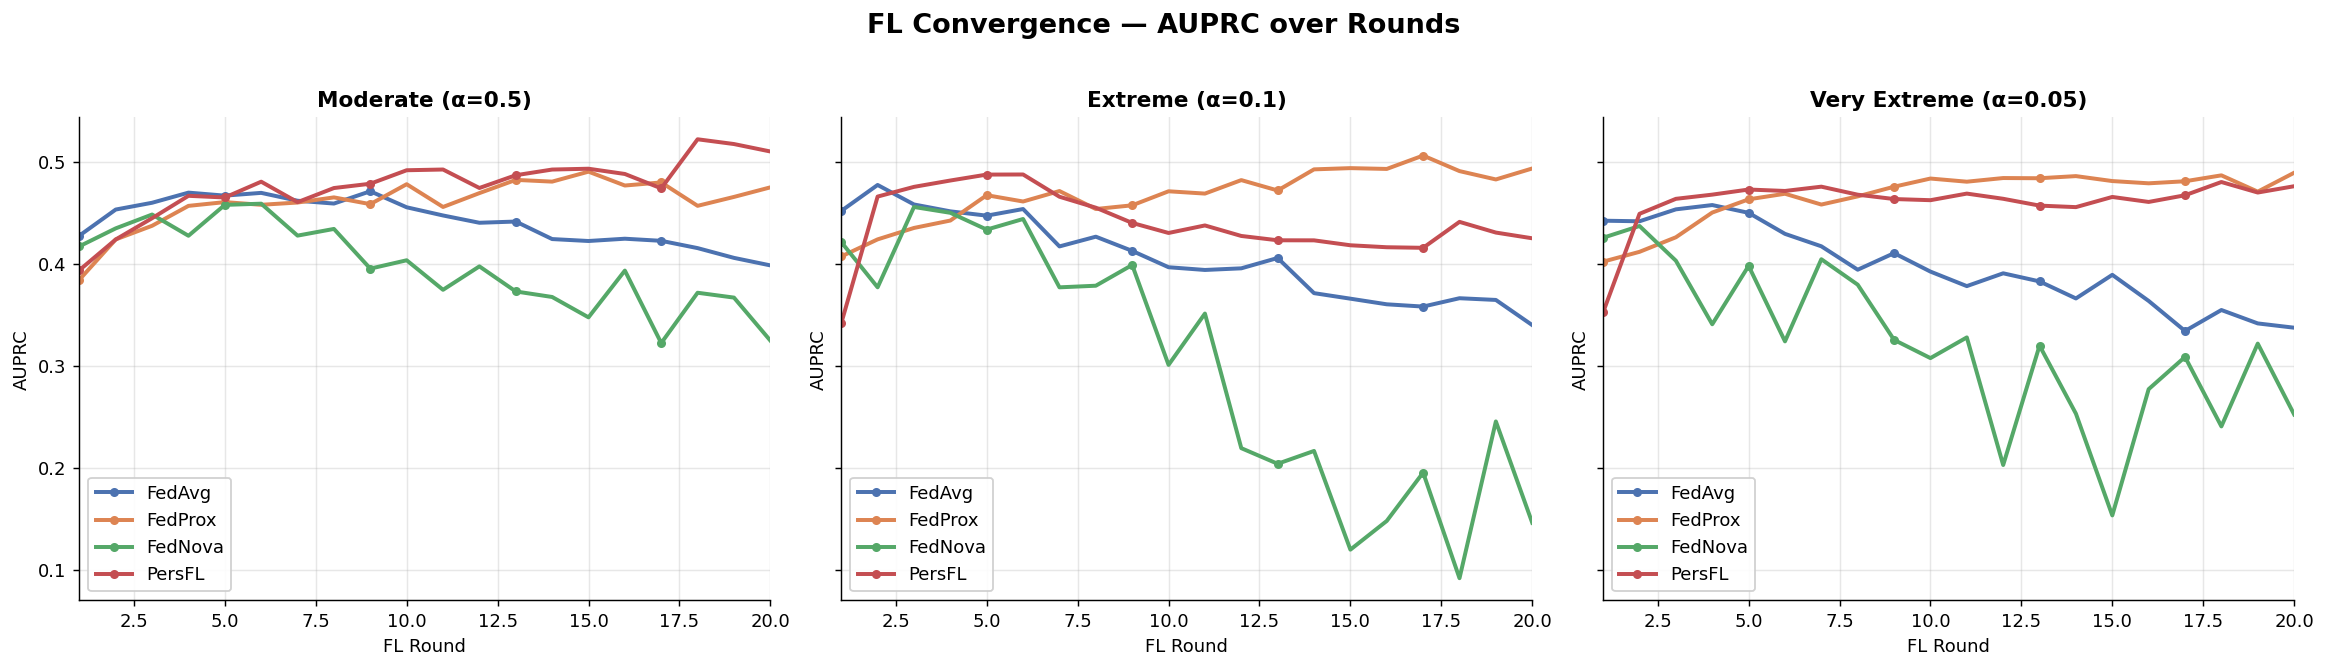

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('FL Convergence — AUPRC over Rounds', fontsize=15, fontweight='bold', y=1.02)

for ax, alpha in zip(axes, CFG['alphas']):
    for algo in FL_ALGOS:
        key = (alpha, algo)
        if key in RESULTS and RESULTS[key]['round_auprc'] is not None:
            ys = RESULTS[key]['round_auprc']
            ax.plot(range(1, len(ys)+1), ys,
                    label=algo, color=PALETTE[algo], linewidth=2.2, marker='o',
                    markersize=4, markevery=4)

    ax.set_title(ALPHA_LABELS[alpha], fontweight='bold')
    ax.set_xlabel('FL Round')
    ax.set_ylabel('AUPRC')
    ax.legend(framealpha=0.9)
    ax.set_xlim(1, CFG['fl_rounds'])

plt.tight_layout()
plt.savefig('plot_01_convergence.png', bbox_inches='tight', dpi=150)
plt.show()

### 8.2 — Primary Metrics Grouped Bar Chart (AUPRC, F1, MCC per Alpha)

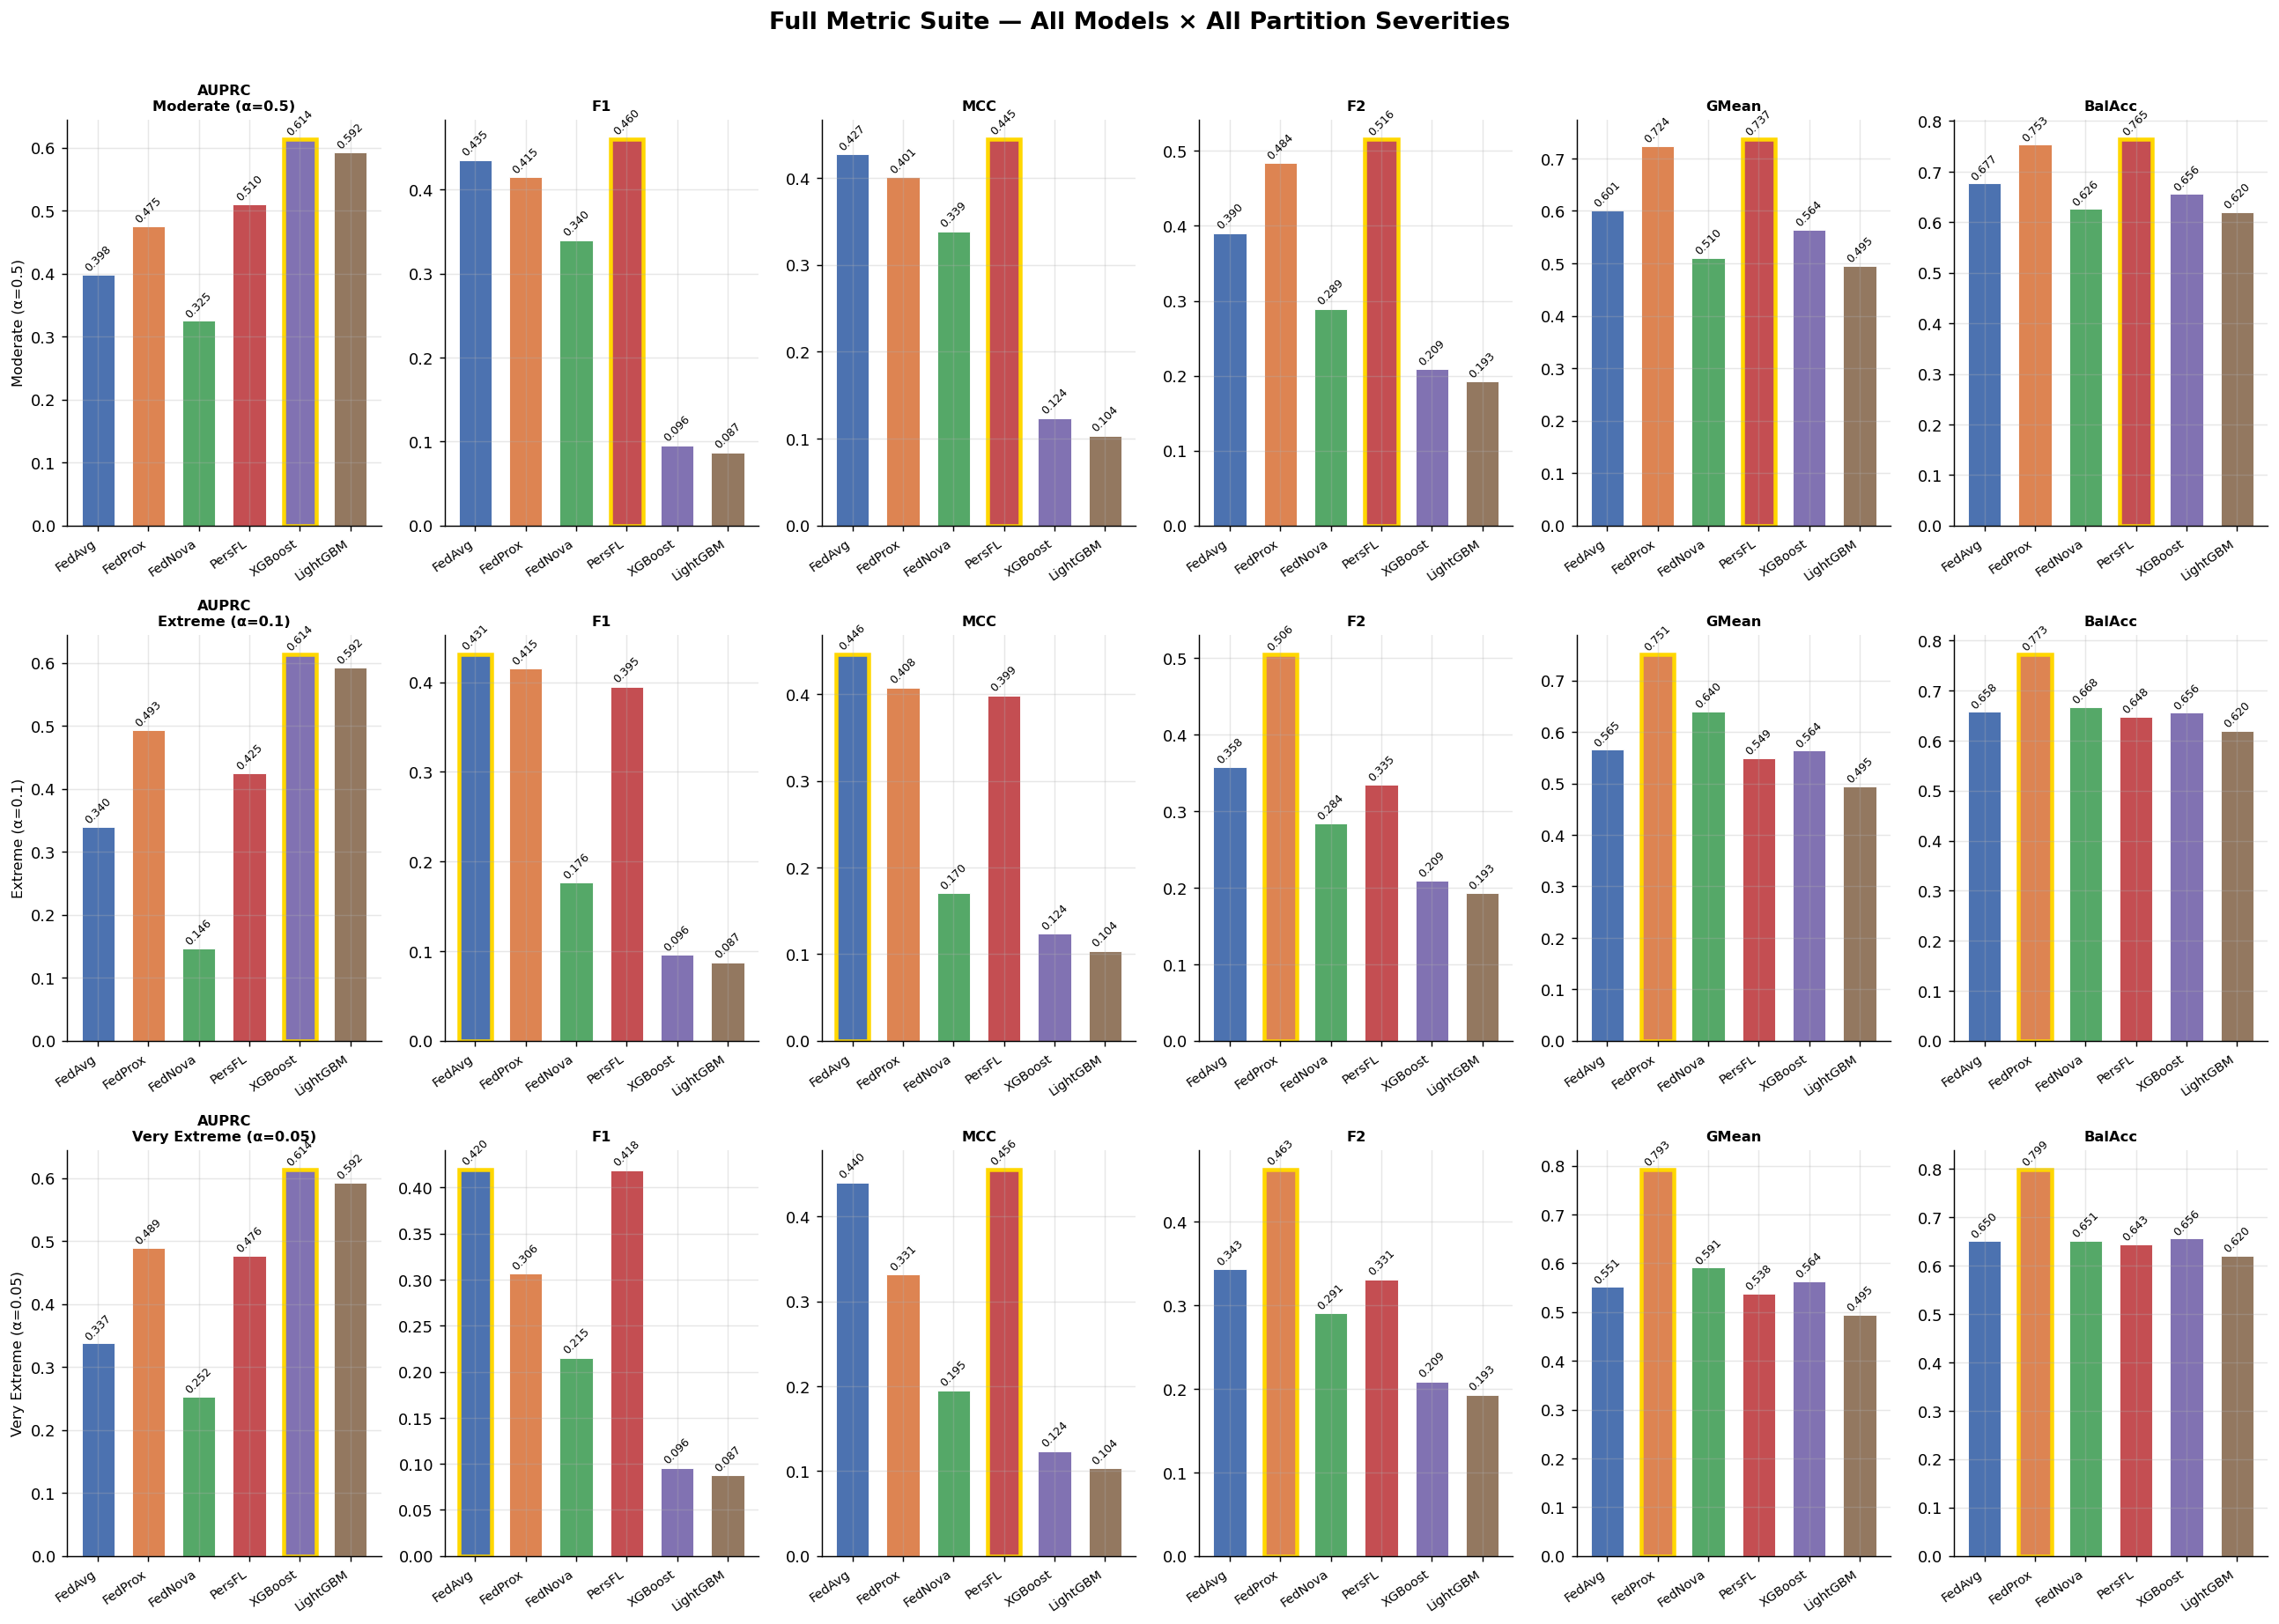

In [10]:
metrics_to_plot = ['AUPRC', 'F1', 'MCC', 'F2', 'GMean', 'BalAcc']
n_metrics = len(metrics_to_plot)
n_models  = len(ALL_MODELS)

fig, axes = plt.subplots(3, n_metrics, figsize=(20, 14), sharex=False)
fig.suptitle('Full Metric Suite — All Models × All Partition Severities',
             fontsize=15, fontweight='bold', y=1.01)

x = np.arange(n_models)
bar_w = 0.65

for row_idx, alpha in enumerate(CFG['alphas']):
    for col_idx, metric in enumerate(metrics_to_plot):
        ax = axes[row_idx, col_idx]
        vals = [RESULTS[(alpha, m)]['final_metrics'][metric] for m in ALL_MODELS]
        colors = [PALETTE[m] for m in ALL_MODELS]
        bars = ax.bar(x, vals, width=bar_w, color=colors, edgecolor='white', linewidth=0.5)

        # Value labels
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

        ax.set_xticks(x)
        ax.set_xticklabels(ALL_MODELS, rotation=35, ha='right', fontsize=8)
        ax.set_title(f'{metric}' + (f'\n{ALPHA_LABELS[alpha]}' if col_idx == 0 else ''),
                     fontsize=9, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(ALPHA_LABELS[alpha], fontsize=9)

        best_idx = int(np.argmax(vals))
        bars[best_idx].set_edgecolor('#FFD700')
        bars[best_idx].set_linewidth(2.5)

plt.tight_layout()
plt.savefig('plot_02_metric_bars.png', bbox_inches='tight', dpi=150)
plt.show()

### 8.3 — AP@K Operational Metrics

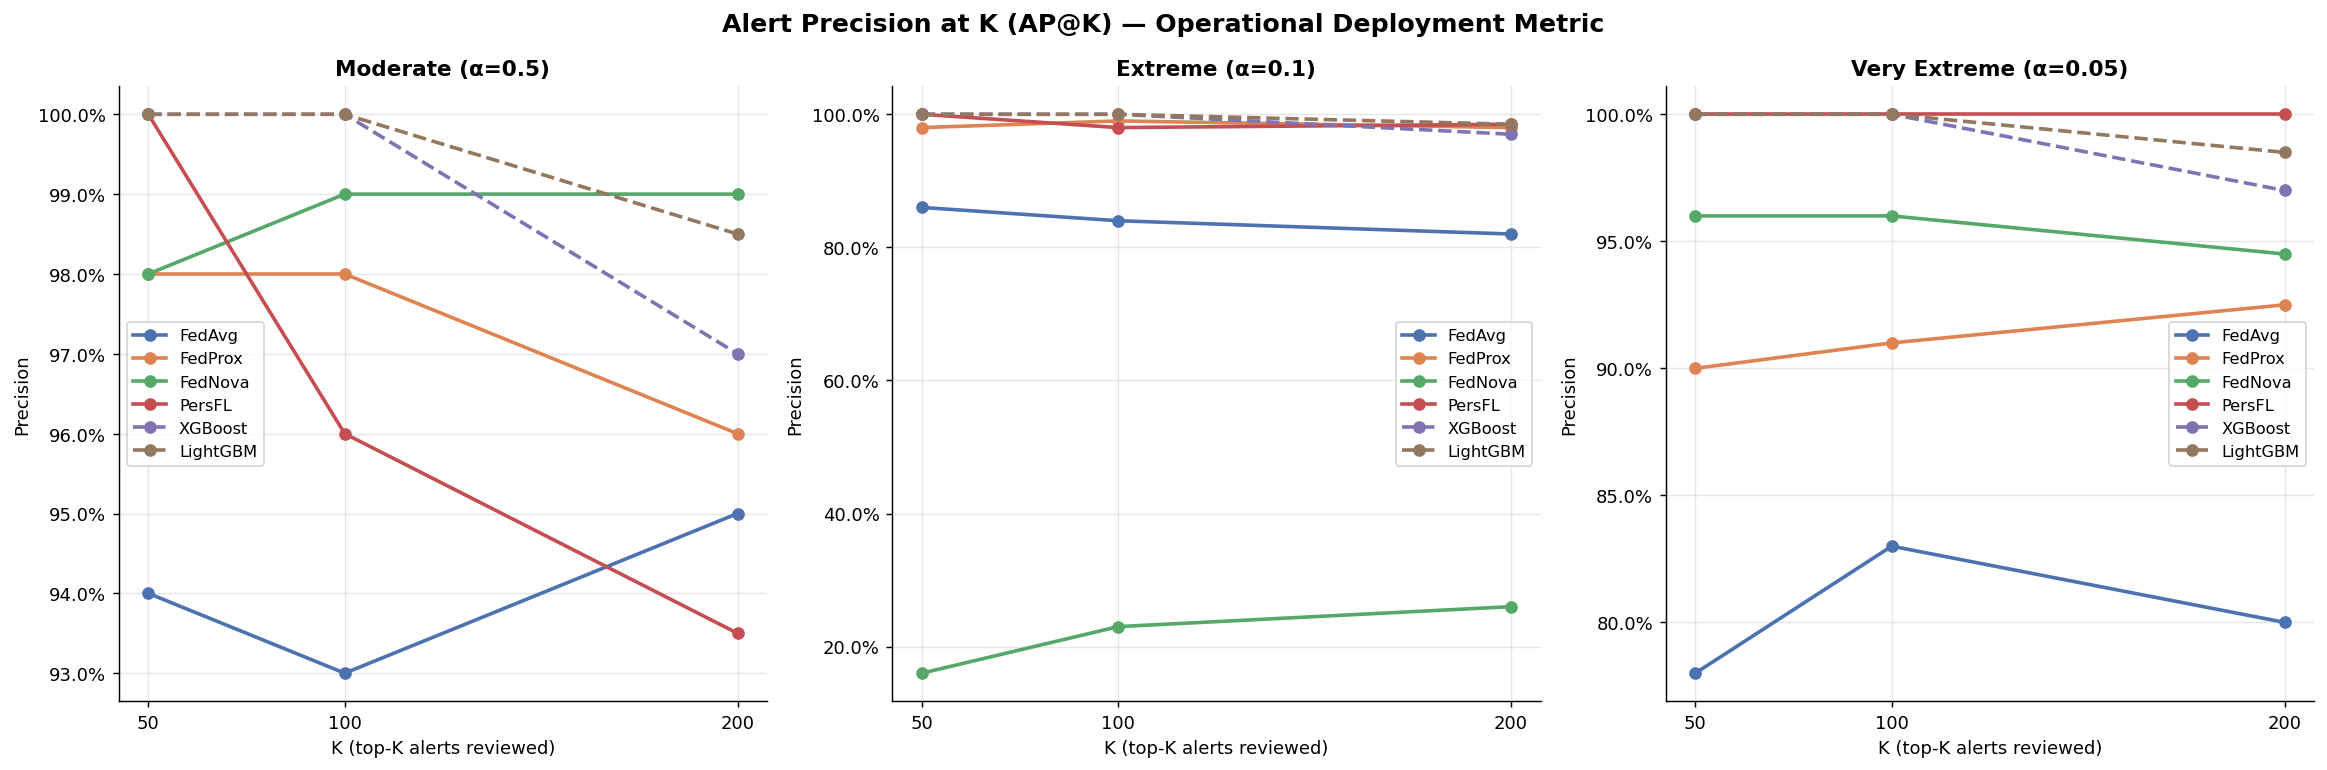

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Alert Precision at K (AP@K) — Operational Deployment Metric',
             fontsize=14, fontweight='bold')

for ax, alpha in zip(axes, CFG['alphas']):
    for model in ALL_MODELS:
        fm = RESULTS[(alpha, model)]['final_metrics']
        ks  = CFG['k_values']
        aps = [fm[f'AP@{k}'] for k in ks]
        ax.plot(ks, aps, marker='o', linewidth=2, label=model,
                color=PALETTE[model],
                linestyle='--' if model in TREE_MODELS else '-')

    ax.set_title(ALPHA_LABELS[alpha], fontweight='bold')
    ax.set_xlabel('K (top-K alerts reviewed)')
    ax.set_ylabel('Precision')
    ax.set_xticks(CFG['k_values'])
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1, decimals=1))

plt.tight_layout()
plt.savefig('plot_03_apk.png', bbox_inches='tight', dpi=150)
plt.show()

### 8.4 — FL Fairness Dashboard (Client Equity, Worst-Bank F1, Collaboration Gain)

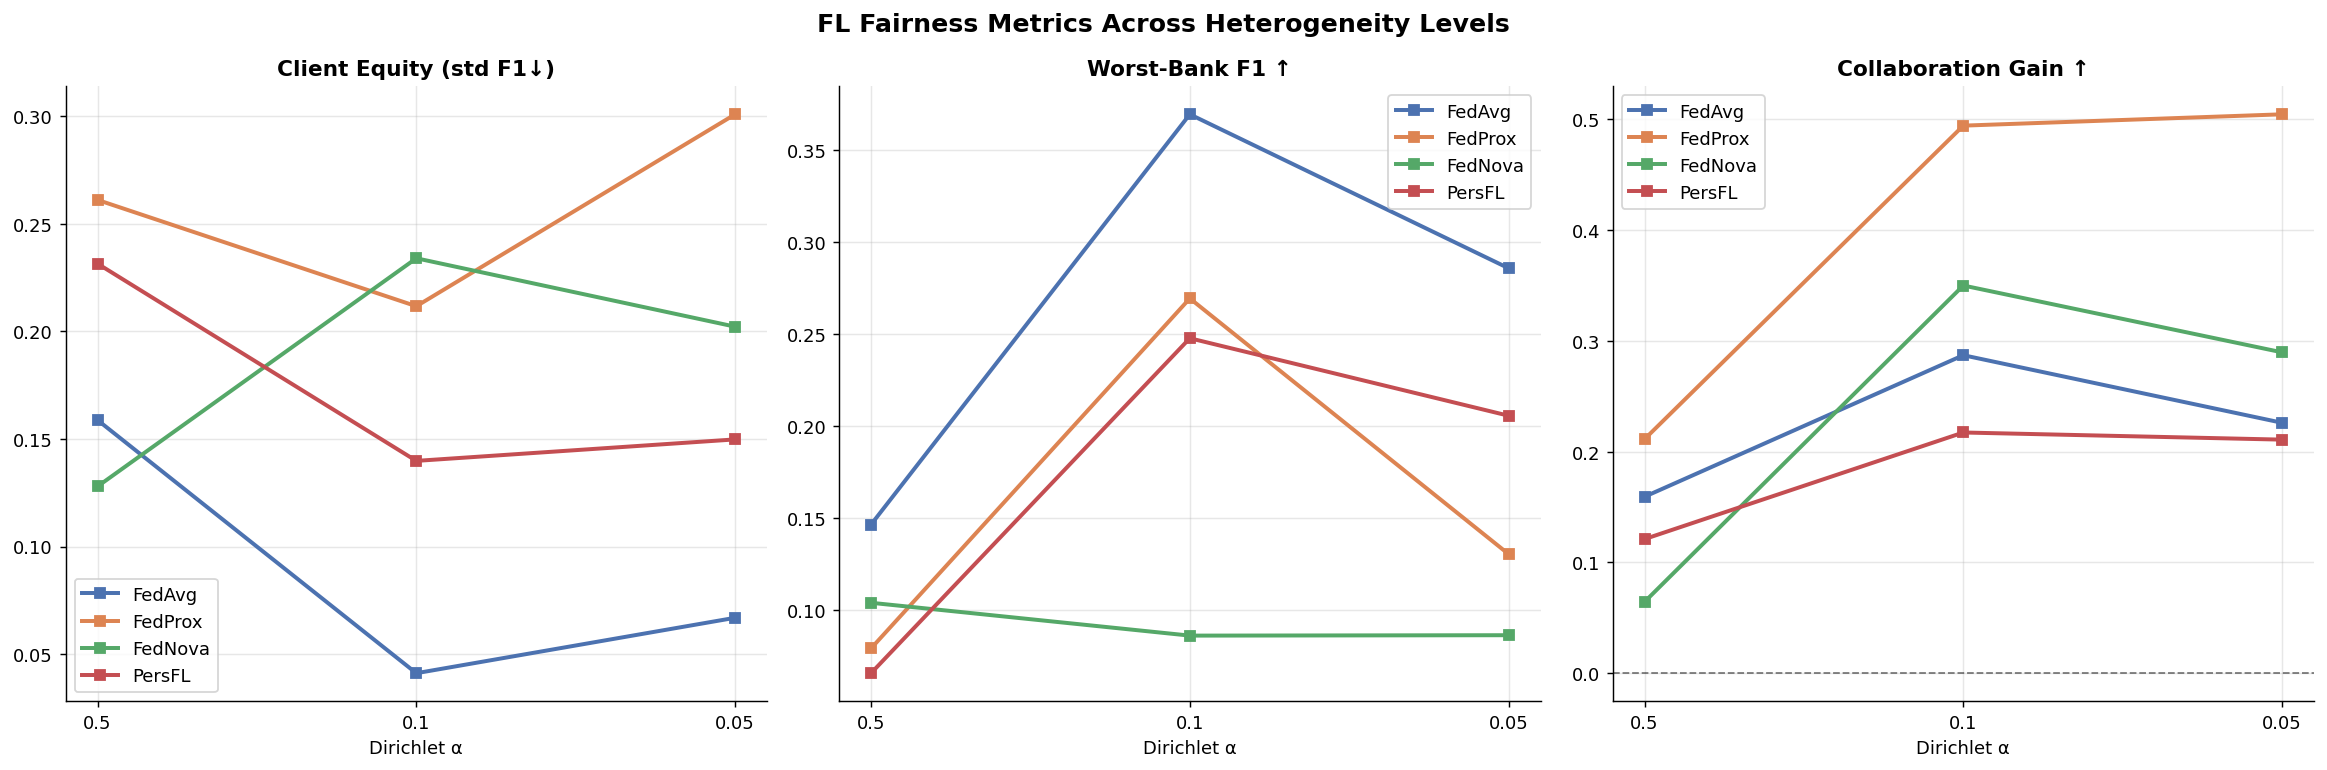

In [12]:
fairness_metrics = ['ClientEquity', 'WorstBankF1', 'CollaborationGain']
fair_labels      = ['Client Equity (std F1↓)', 'Worst-Bank F1 ↑', 'Collaboration Gain ↑']
# Lower ClientEquity is better → invert for display

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('FL Fairness Metrics Across Heterogeneity Levels',
             fontsize=14, fontweight='bold')

for ax, fm_key, fm_label in zip(axes, fairness_metrics, fair_labels):
    for model in FL_ALGOS:  # only FL models have meaningful fairness metrics
        vals = [RESULTS[(a, model)]['fairness'][fm_key] for a in CFG['alphas']]
        ax.plot([str(a) for a in CFG['alphas']], vals,
                marker='s', linewidth=2.2, label=model, color=PALETTE[model])

    ax.set_title(fm_label, fontweight='bold')
    ax.set_xlabel('Dirichlet α')
    ax.legend()
    if fm_key == 'CollaborationGain':
        ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('plot_04_fairness.png', bbox_inches='tight', dpi=150)
plt.show()

### 8.5 — Per-Bank Collaboration Gain Heatmap

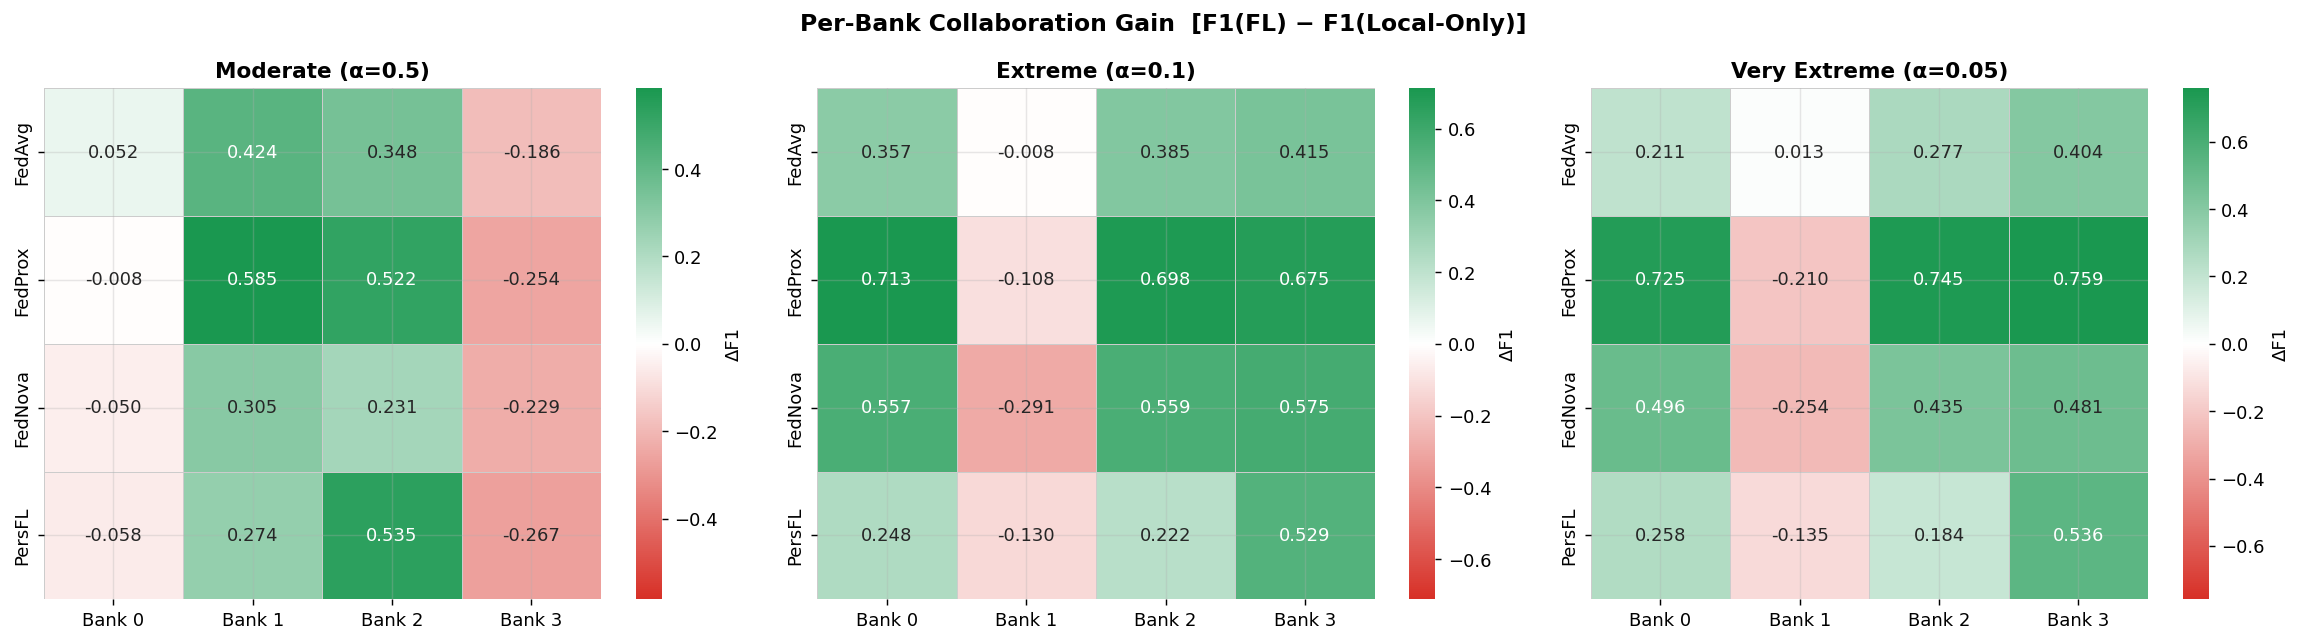

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Per-Bank Collaboration Gain  [F1(FL) − F1(Local-Only)]',
             fontsize=13, fontweight='bold')

cmap = LinearSegmentedColormap.from_list('rg', ['#d73027','#ffffff','#1a9850'])

for ax, alpha in zip(axes, CFG['alphas']):
    matrix = np.array([
        RESULTS[(alpha, algo)]['fairness']['CollabGainPerBank']
        for algo in FL_ALGOS
    ])
    vmax = max(abs(matrix).max(), 0.01)
    sns.heatmap(
        matrix, ax=ax,
        xticklabels=[f'Bank {i}' for i in range(CFG['n_banks'])],
        yticklabels=FL_ALGOS,
        annot=True, fmt='.3f', cmap=cmap,
        vmin=-vmax, vmax=vmax,
        linewidths=0.5, linecolor='#cccccc',
        cbar_kws={'label': 'ΔF1'},
    )
    ax.set_title(ALPHA_LABELS[alpha], fontweight='bold')

plt.tight_layout()
plt.savefig('plot_05_collab_gain_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

### 8.6 — Typology Coverage & Weighted F1

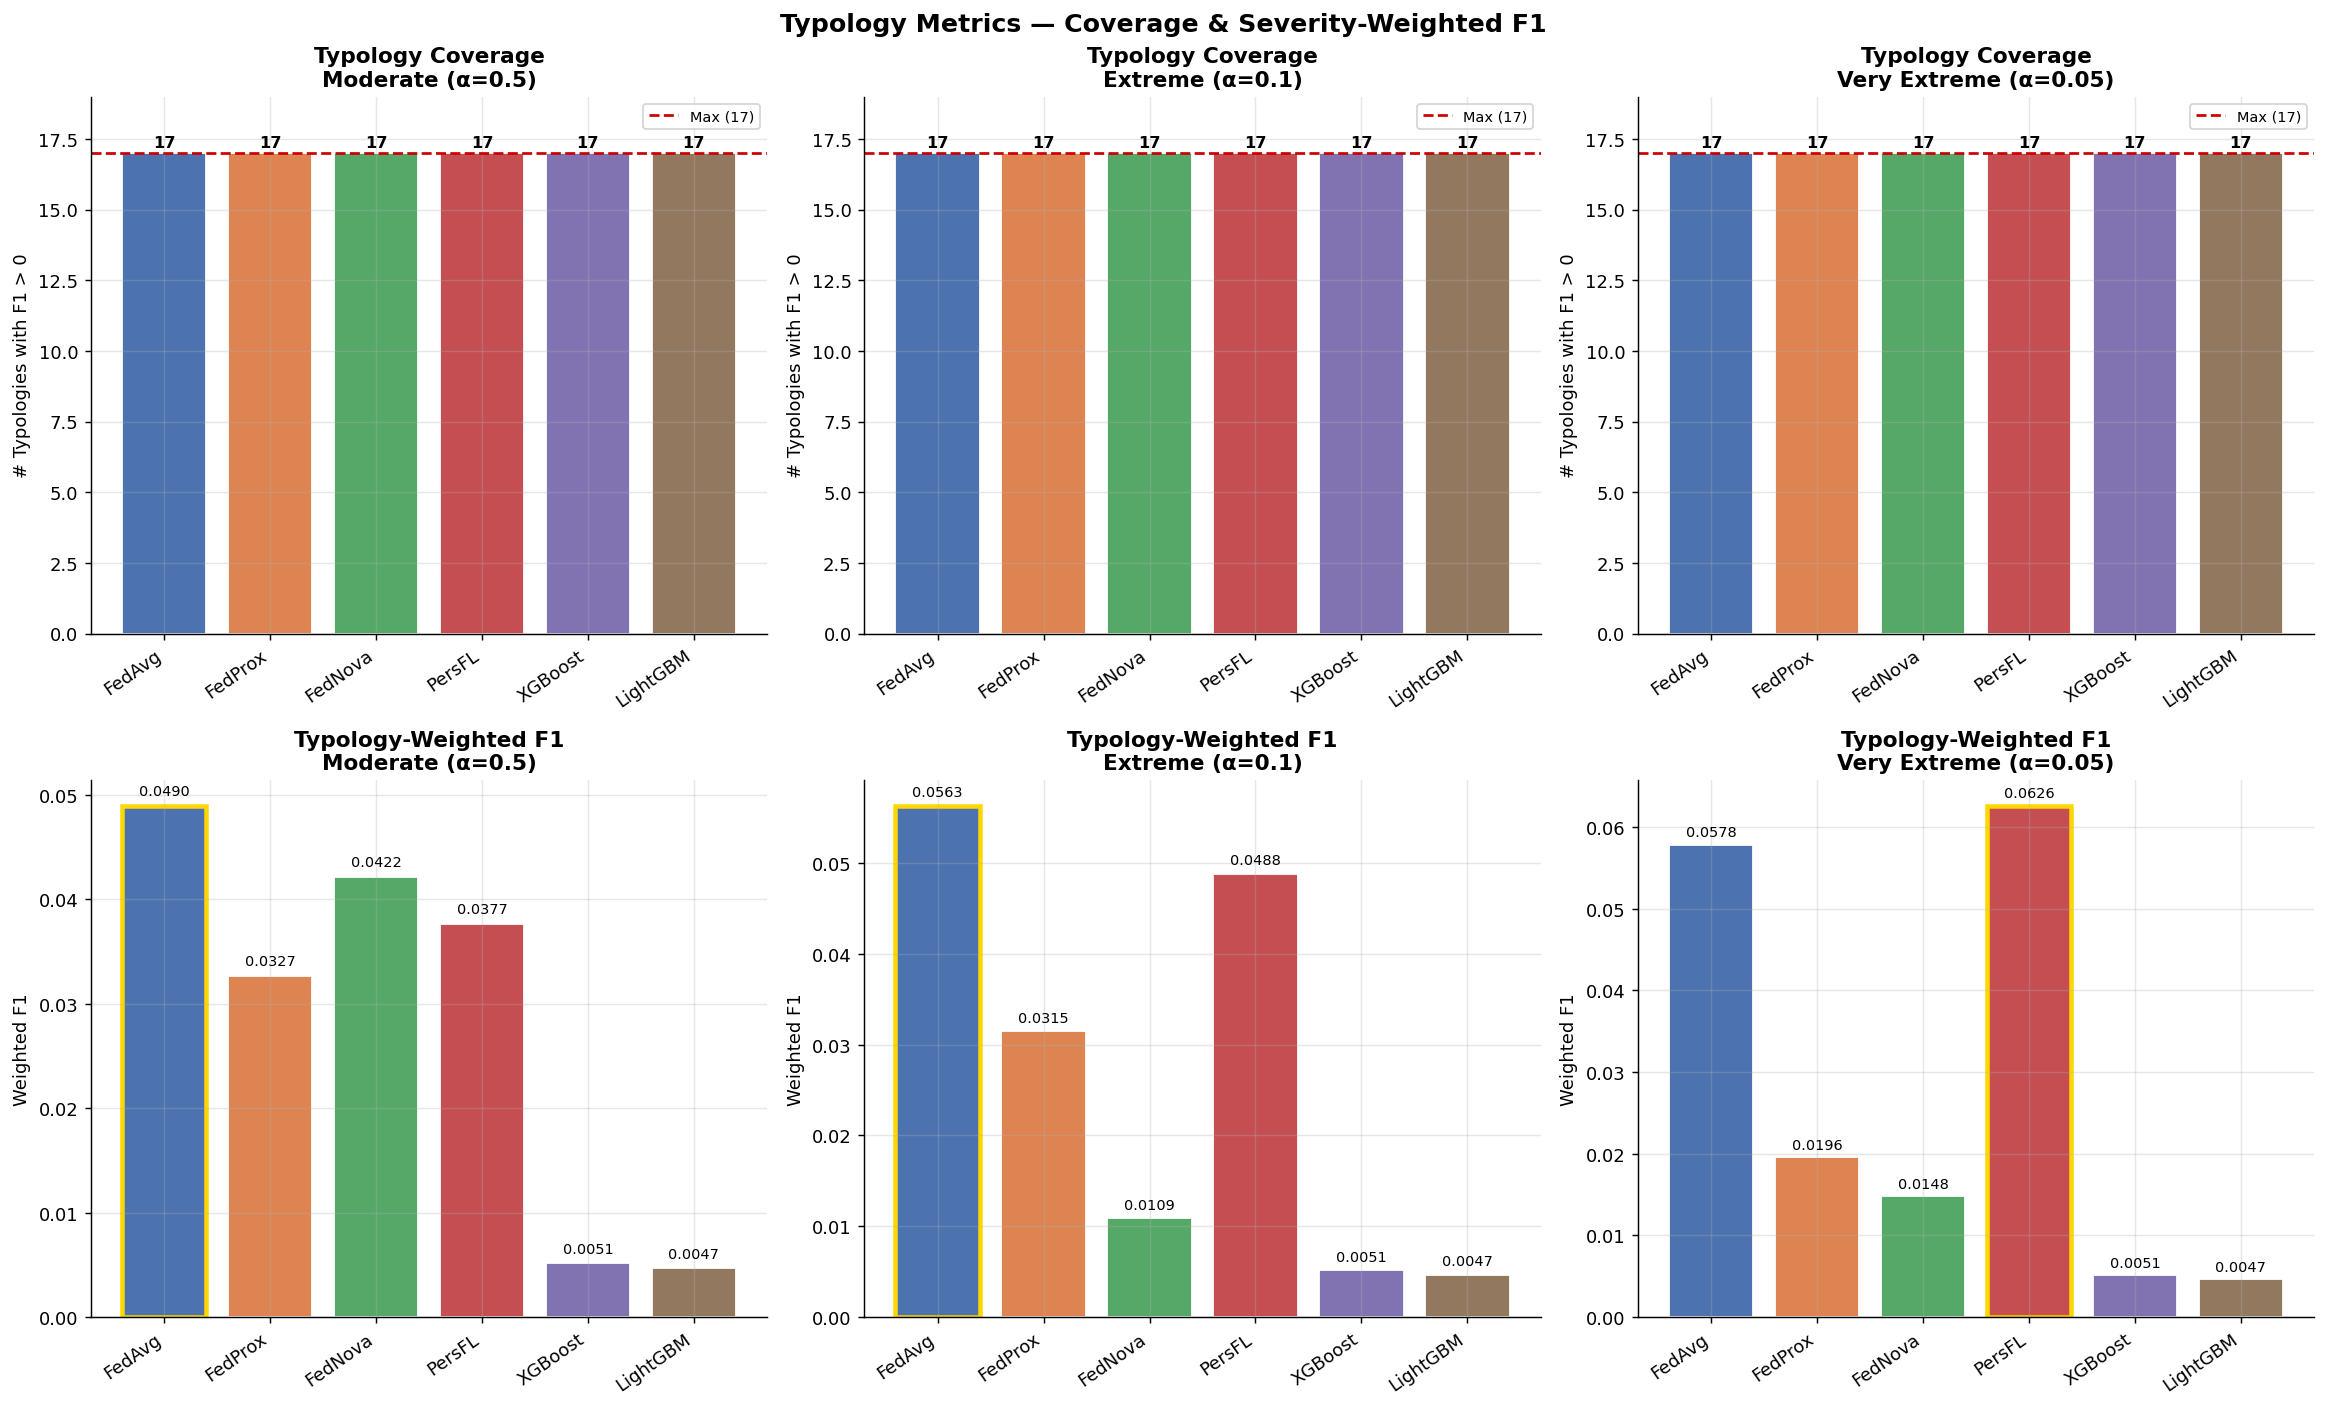

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Typology Metrics — Coverage & Severity-Weighted F1',
             fontsize=14, fontweight='bold')

for col_idx, alpha in enumerate(CFG['alphas']):
    # --- Coverage ---
    ax_top = axes[0, col_idx]
    covs = [RESULTS[(alpha, m)]['final_metrics']['TypologyCoverage'] for m in ALL_MODELS]
    bars = ax_top.bar(ALL_MODELS, covs,
                      color=[PALETTE[m] for m in ALL_MODELS],
                      edgecolor='white')
    ax_top.axhline(len(TYPOLOGY_NAMES), color='#cc0000', linestyle='--',
                   linewidth=1.5, label=f'Max ({len(TYPOLOGY_NAMES)})')
    ax_top.set_ylim(0, len(TYPOLOGY_NAMES) + 2)
    ax_top.set_title(f'Typology Coverage\n{ALPHA_LABELS[alpha]}', fontweight='bold')
    ax_top.set_ylabel('# Typologies with F1 > 0')
    ax_top.set_xticklabels(ALL_MODELS, rotation=35, ha='right')
    ax_top.legend(fontsize=8)
    for bar, v in zip(bars, covs):
        ax_top.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                    str(v), ha='center', fontsize=9, fontweight='bold')

    # --- Weighted F1 ---
    ax_bot = axes[1, col_idx]
    wf1s = [RESULTS[(alpha, m)]['final_metrics']['TypologyWeightedF1'] for m in ALL_MODELS]
    bars = ax_bot.bar(ALL_MODELS, wf1s,
                      color=[PALETTE[m] for m in ALL_MODELS],
                      edgecolor='white')
    ax_bot.set_title(f'Typology-Weighted F1\n{ALPHA_LABELS[alpha]}', fontweight='bold')
    ax_bot.set_ylabel('Weighted F1')
    ax_bot.set_xticklabels(ALL_MODELS, rotation=35, ha='right')
    for bar, v in zip(bars, wf1s):
        ax_bot.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                    f'{v:.4f}', ha='center', fontsize=8)
    best_idx = int(np.argmax(wf1s))
    bars[best_idx].set_edgecolor('#FFD700')
    bars[best_idx].set_linewidth(2.5)

plt.tight_layout()
plt.savefig('plot_06_typology.png', bbox_inches='tight', dpi=150)
plt.show()

### 8.7 — Per-Typology F1 Heatmap (Best Model per Alpha)

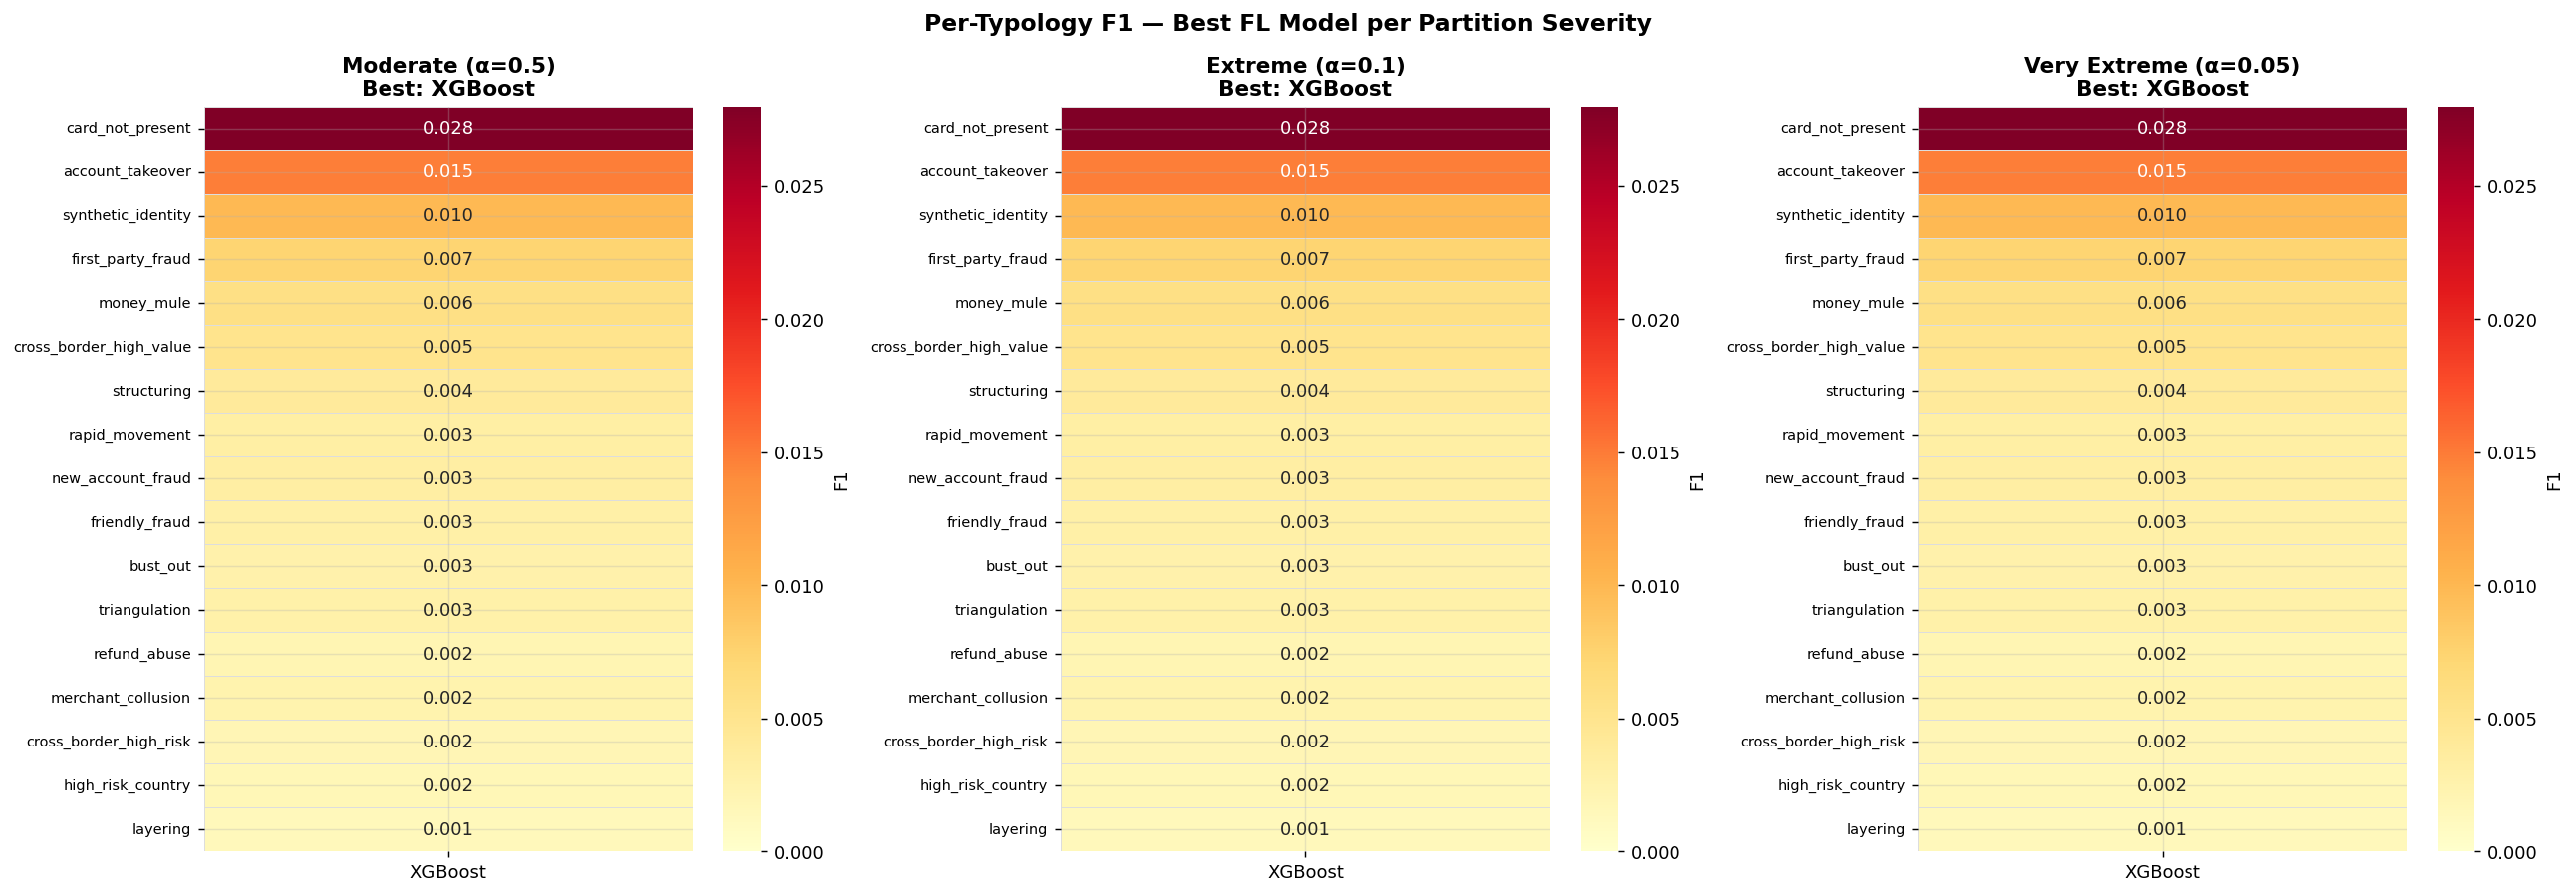

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Per-Typology F1 — Best FL Model per Partition Severity',
             fontsize=13, fontweight='bold')

for ax, alpha in zip(axes, CFG['alphas']):
    # Find best model by AUPRC
    best_model = max(ALL_MODELS,
                     key=lambda m: RESULTS[(alpha, m)]['final_metrics']['AUPRC'])

    typo_f1s = np.array(RESULTS[(alpha, best_model)]['final_metrics']['TypologyF1s'])
    # Reshape for heatmap
    data = typo_f1s.reshape(-1, 1)
    sns.heatmap(
        data, ax=ax,
        yticklabels=TYPOLOGY_NAMES,
        xticklabels=[best_model],
        annot=True, fmt='.3f',
        cmap='YlOrRd', vmin=0, vmax=max(typo_f1s.max(), 0.01),
        linewidths=0.3, linecolor='#dddddd',
        cbar_kws={'label': 'F1'},
    )
    ax.set_title(f'{ALPHA_LABELS[alpha]}\nBest: {best_model}', fontweight='bold')
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

plt.tight_layout()
plt.savefig('plot_07_typology_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

### 8.8 — Dirichlet Partition Visualisation (Fraud Distribution per Bank)

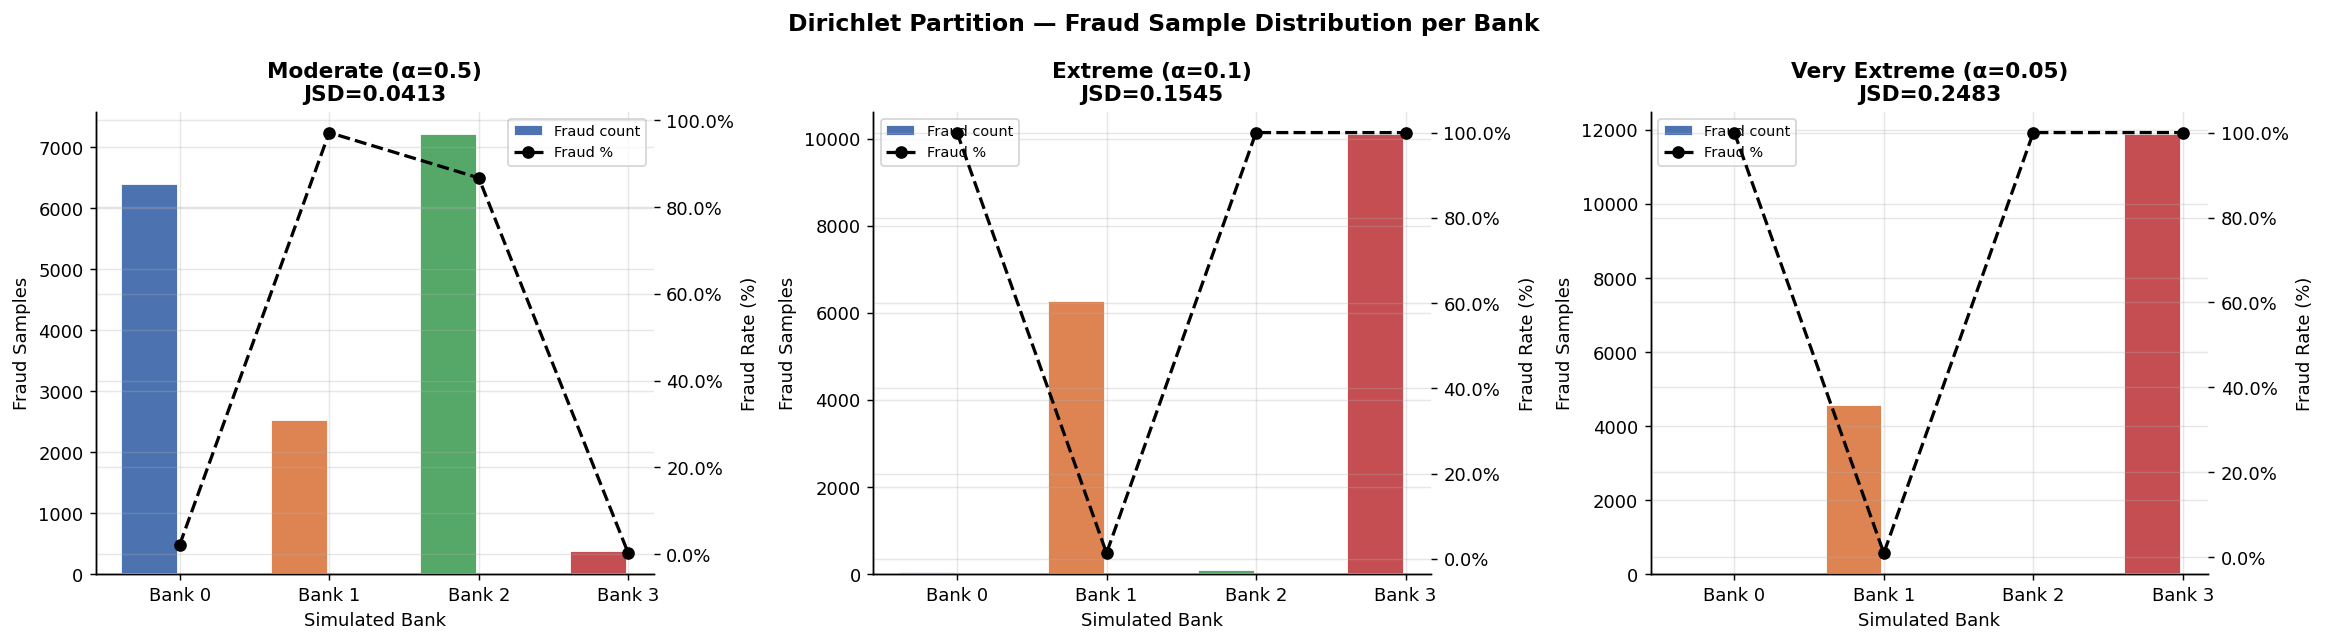

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dirichlet Partition — Fraud Sample Distribution per Bank',
             fontsize=13, fontweight='bold')

bank_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, alpha in zip(axes, CFG['alphas']):
    clients = partition_cache[alpha]
    fraud_counts  = [int(yc.sum()) for _, yc, _ in clients]
    total_samples = [len(yc) for _, yc, _ in clients]
    fraud_pcts    = [f / t * 100 for f, t in zip(fraud_counts, total_samples)]

    x = np.arange(CFG['n_banks'])
    bars1 = ax.bar(x - 0.2, fraud_counts, width=0.38,
                   color=bank_colors, label='Fraud count', edgecolor='white')
    ax2 = ax.twinx()
    ax2.plot(x, fraud_pcts, 'k--o', linewidth=1.8, label='Fraud %')
    ax2.set_ylabel('Fraud Rate (%)')
    ax2.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%.1f%%'))

    ax.set_xticks(x)
    ax.set_xticklabels([f'Bank {i}' for i in range(CFG['n_banks'])])
    ax.set_title(f'{ALPHA_LABELS[alpha]}\nJSD={jsd_cache[alpha]:.4f}', fontweight='bold')
    ax.set_ylabel('Fraud Samples')
    ax.set_xlabel('Simulated Bank')

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.tight_layout()
plt.savefig('plot_08_partition.png', bbox_inches='tight', dpi=150)
plt.show()

### 8.9 — Radar Chart: Model Capability Profile (α=0.1)

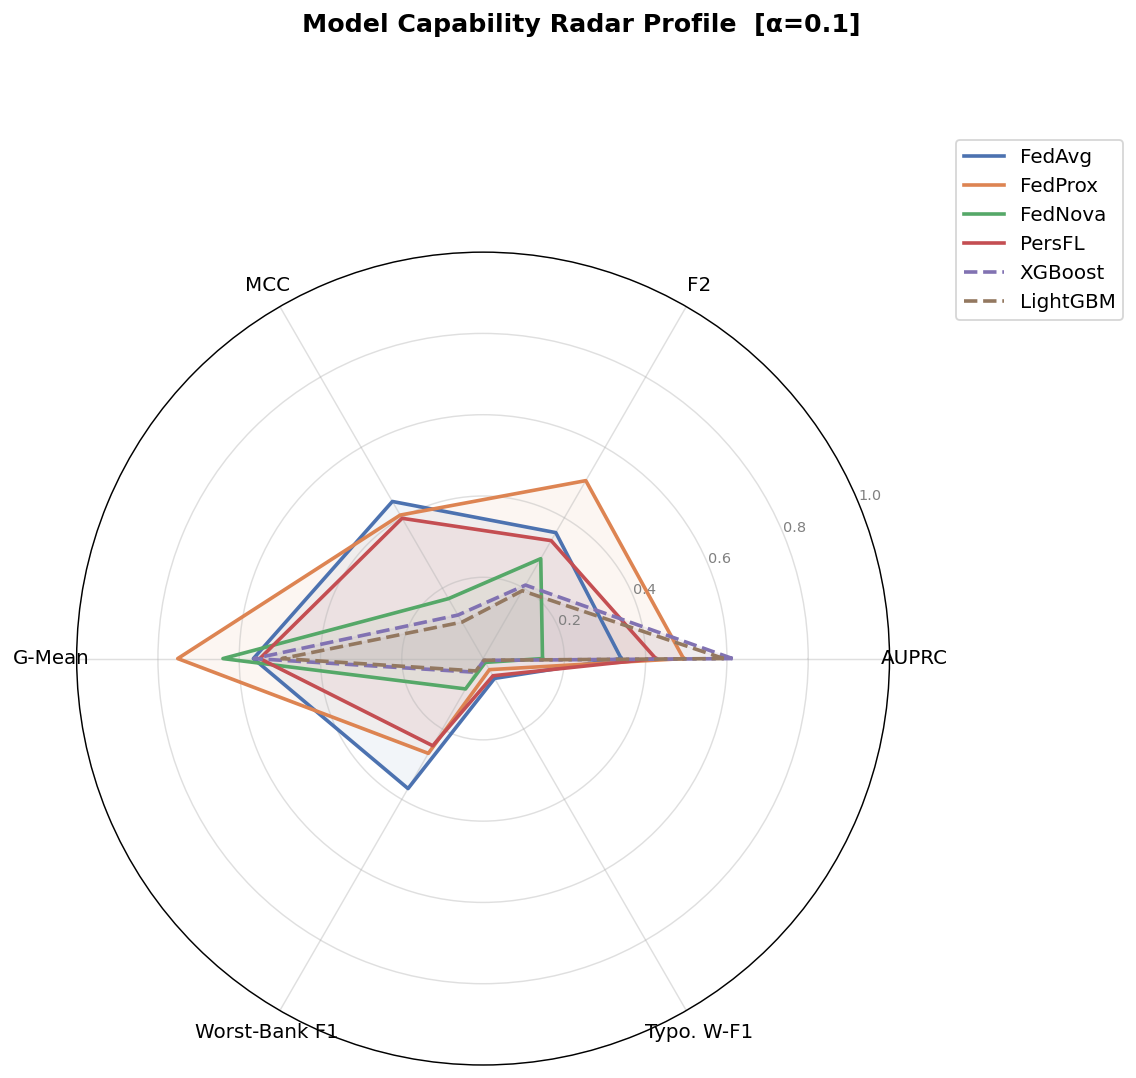

In [17]:
radar_metrics  = ['AUPRC', 'F2', 'MCC', 'GMean', 'WorstBankF1', 'TypologyWeightedF1']
radar_labels   = ['AUPRC', 'F2', 'MCC', 'G-Mean', 'Worst-Bank F1', 'Typo. W-F1']
alpha_radar    = 0.1

def get_radar_vals(model, alpha):
    fm = RESULTS[(alpha, model)]['final_metrics']
    fa = RESULTS[(alpha, model)]['fairness']
    vals = [
        fm['AUPRC'], fm['F2'], max(fm['MCC'], 0),  # clip negative MCC at 0 for radar
        fm['GMean'], fa['WorstBankF1'], fm['TypologyWeightedF1']
    ]
    return vals

angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
fig.suptitle(f'Model Capability Radar Profile  [α={alpha_radar}]',
             fontsize=14, fontweight='bold')

for model in ALL_MODELS:
    vals = get_radar_vals(model, alpha_radar)
    vals += vals[:1]
    ls = '--' if model in TREE_MODELS else '-'
    ax.plot(angles, vals, linewidth=2, linestyle=ls,
            label=model, color=PALETTE[model])
    ax.fill(angles, vals, alpha=0.07, color=PALETTE[model])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=8, color='grey')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=11)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('plot_09_radar.png', bbox_inches='tight', dpi=150)
plt.show()

### 8.10 — Heterogeneity Impact: AUPRC vs Typology JSD

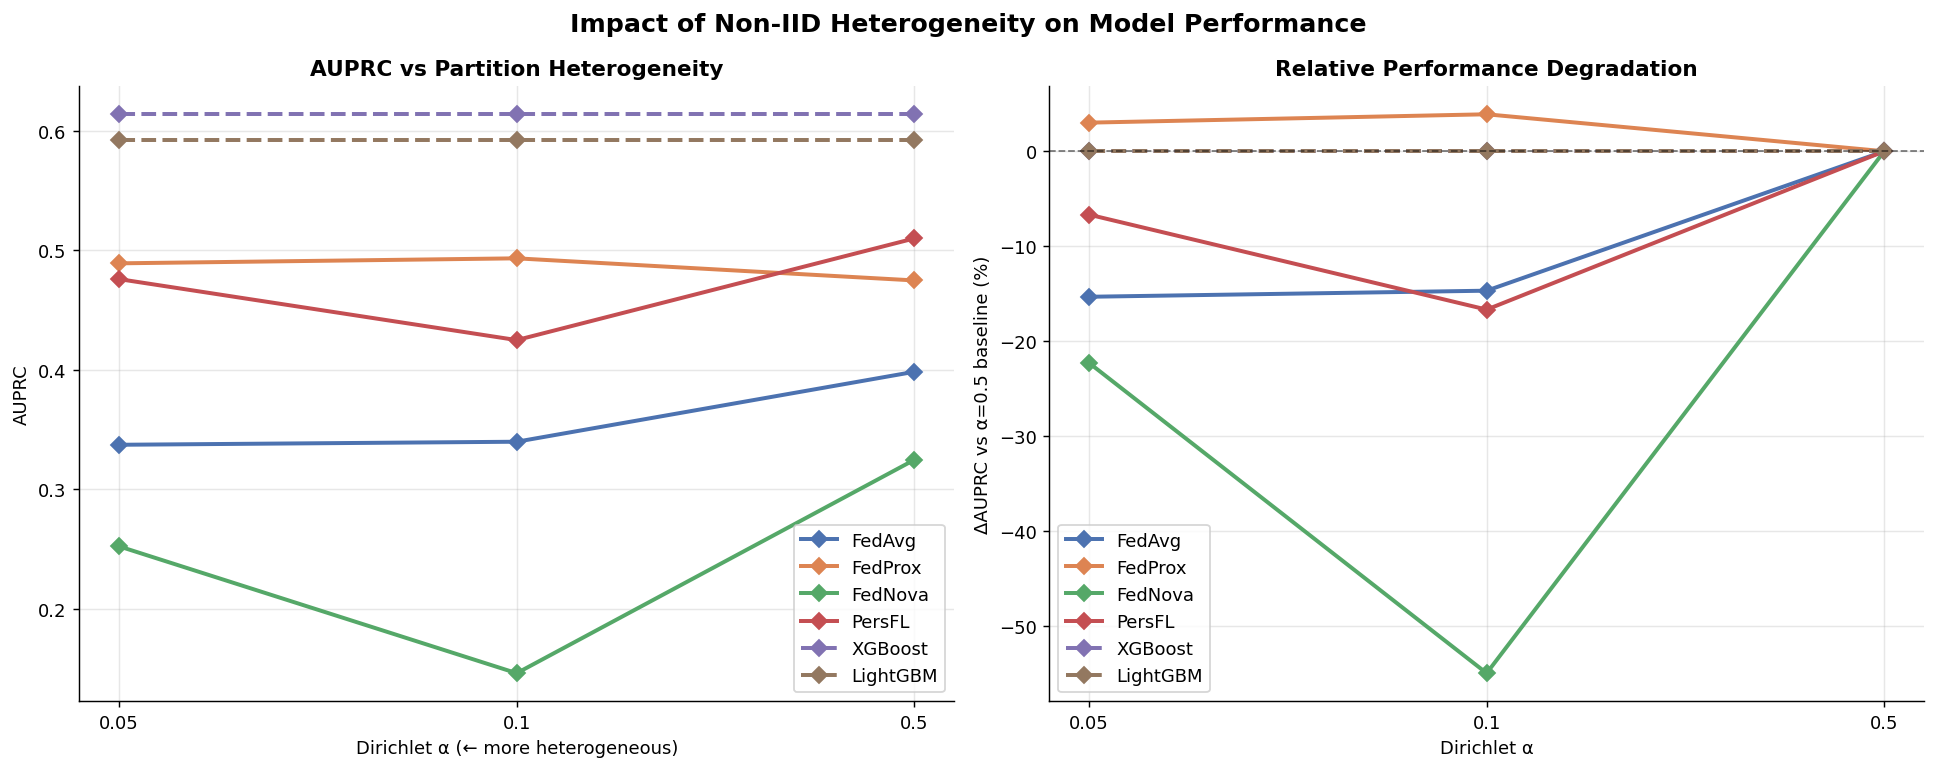

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Impact of Non-IID Heterogeneity on Model Performance',
             fontsize=14, fontweight='bold')

# ── Left: AUPRC vs Alpha ─────────────────────────────────────────────────────
ax = axes[0]
for model in ALL_MODELS:
    ys = [RESULTS[(a, model)]['final_metrics']['AUPRC'] for a in CFG['alphas']]
    xs = [str(a) for a in CFG['alphas']]
    ls = '--' if model in TREE_MODELS else '-'
    ax.plot(xs, ys, marker='D', linewidth=2.2, linestyle=ls,
            label=model, color=PALETTE[model])

ax.set_xlabel('Dirichlet α (← more heterogeneous)')
ax.set_ylabel('AUPRC')
ax.set_title('AUPRC vs Partition Heterogeneity', fontweight='bold')
ax.legend()
ax.invert_xaxis()  # most extreme on right

# ── Right: Performance degradation (relative to α=0.5 baseline) ──────────────
ax = axes[1]
for model in ALL_MODELS:
    base = RESULTS[(0.5, model)]['final_metrics']['AUPRC']
    deltas = [
        (RESULTS[(a, model)]['final_metrics']['AUPRC'] - base) / max(base, 1e-8) * 100
        for a in CFG['alphas']
    ]
    xs = [str(a) for a in CFG['alphas']]
    ls = '--' if model in TREE_MODELS else '-'
    ax.plot(xs, deltas, marker='D', linewidth=2.2, linestyle=ls,
            label=model, color=PALETTE[model])

ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlabel('Dirichlet α')
ax.set_ylabel('ΔAUPRC vs α=0.5 baseline (%)')
ax.set_title('Relative Performance Degradation', fontweight='bold')
ax.legend()
ax.invert_xaxis()

plt.tight_layout()
plt.savefig('plot_10_heterogeneity_impact.png', bbox_inches='tight', dpi=150)
plt.show()

### 8.11 — Comprehensive Metric Heatmap (Model × Metric × Alpha)

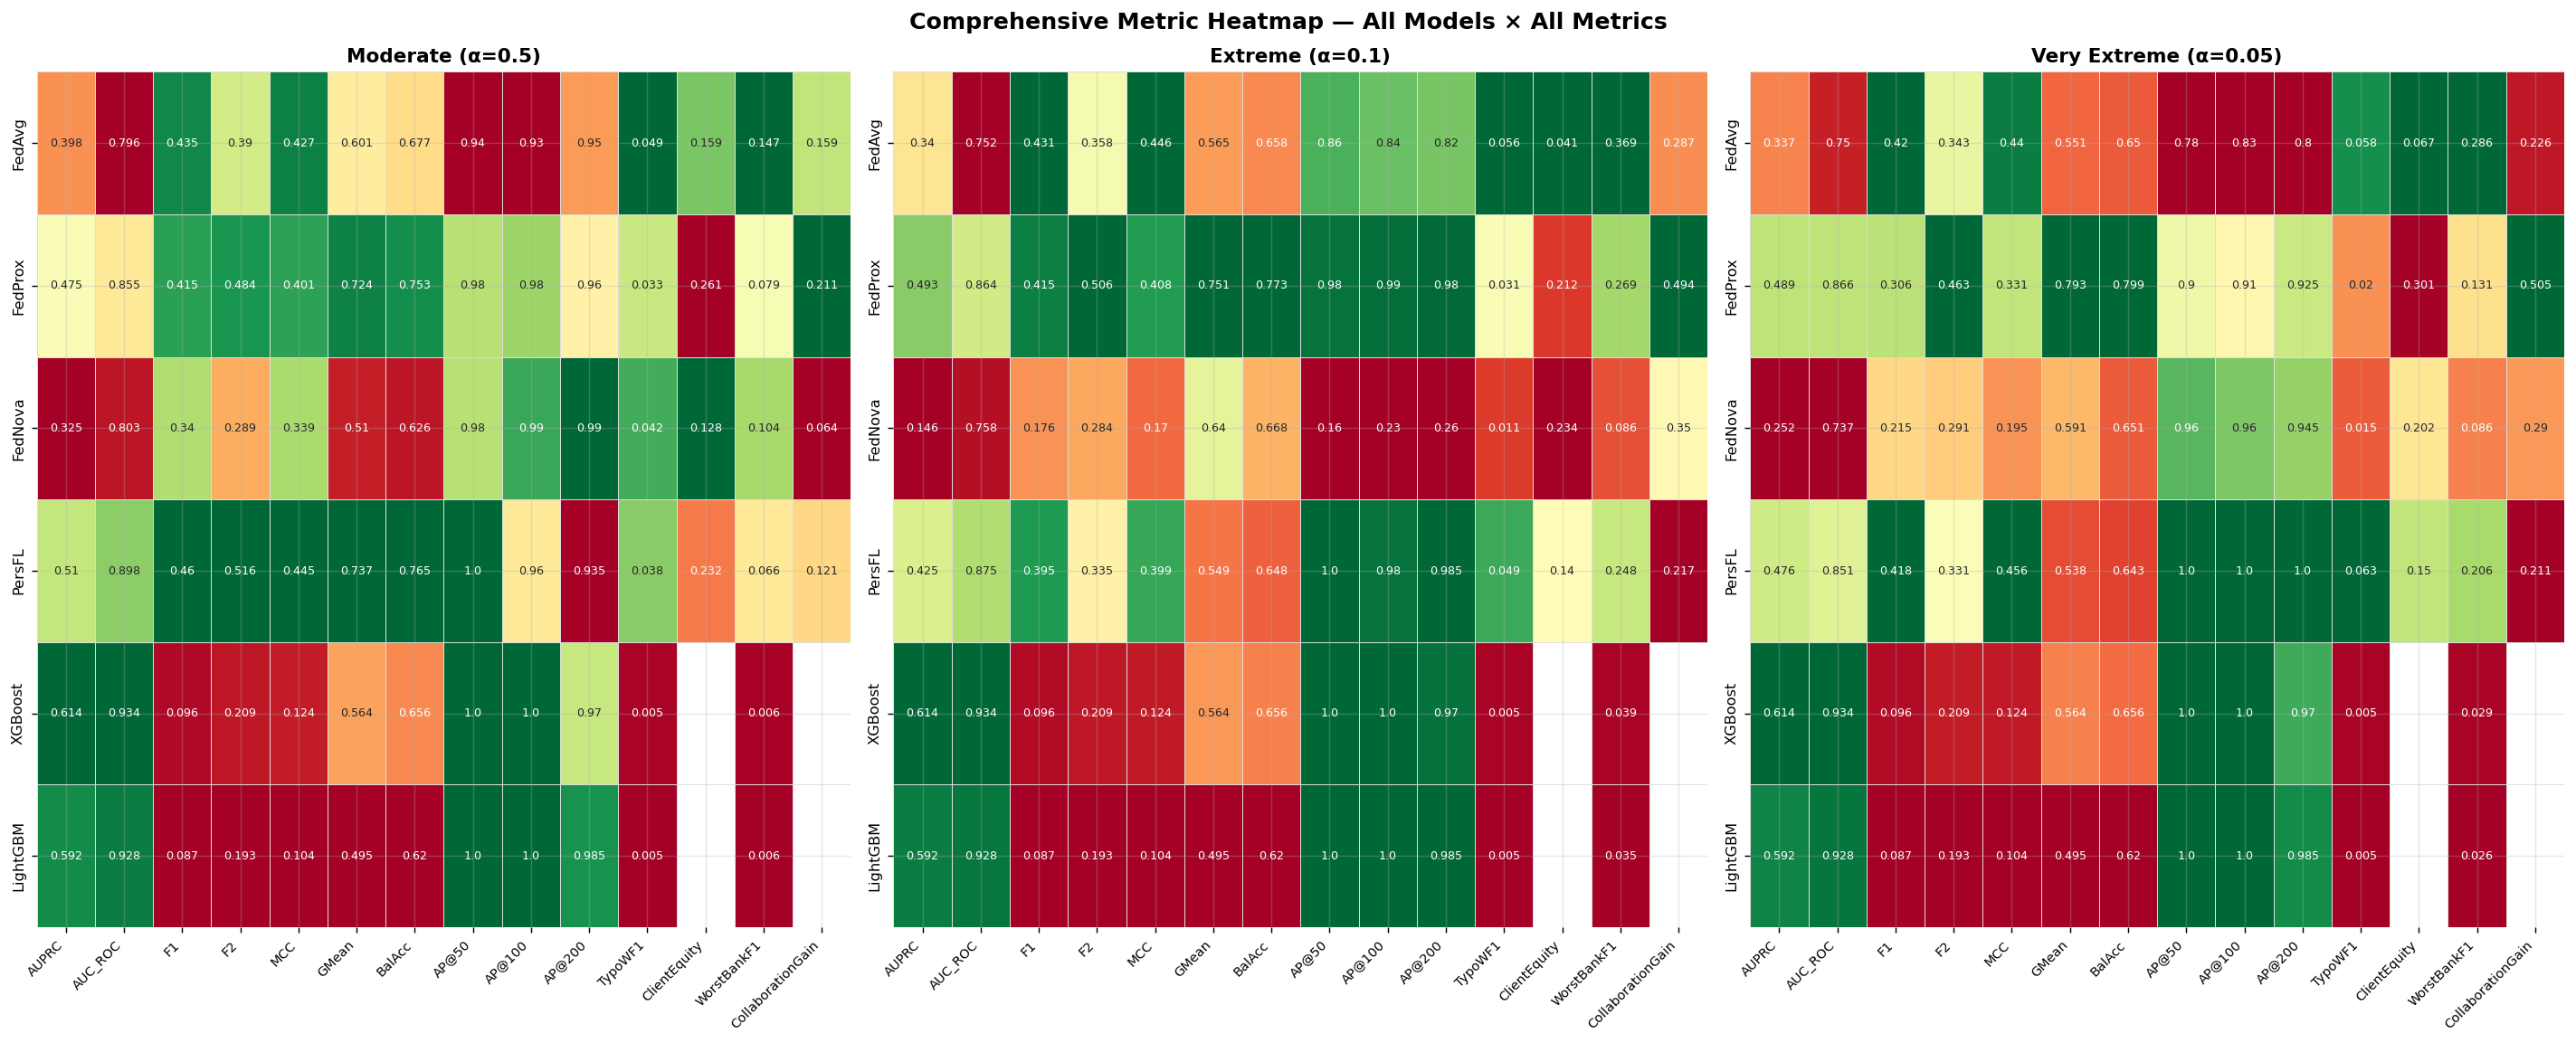

In [19]:
hm_metrics = ['AUPRC', 'AUC_ROC', 'F1', 'F2', 'MCC', 'GMean', 'BalAcc',
               'AP@50', 'AP@100', 'AP@200', 'TypoWF1', 'ClientEquity', 'WorstBankF1', 'CollaborationGain']

fig, axes = plt.subplots(1, 3, figsize=(22, 9))
fig.suptitle('Comprehensive Metric Heatmap — All Models × All Metrics',
             fontsize=14, fontweight='bold')

for ax, alpha in zip(axes, CFG['alphas']):
    rows = []
    for model in ALL_MODELS:
        fm = RESULTS[(alpha, model)]['final_metrics']
        fa = RESULTS[(alpha, model)]['fairness']
        row = [
            fm['AUPRC'], fm['AUC_ROC'], fm['F1'], fm['F2'],
            fm['MCC'], fm['GMean'], fm['BalAcc'],
            fm['AP@50'], fm['AP@100'], fm['AP@200'],
            fm['TypologyWeightedF1'],
            fa['ClientEquity'] if model in FL_ALGOS else np.nan,
            fa['WorstBankF1'],
            fa['CollaborationGain'] if model in FL_ALGOS else np.nan,
        ]
        rows.append(row)

    mat = np.array(rows, dtype=float)
    # Normalise each column for color (0–1), handle NaN
    mat_norm = mat.copy()
    for j in range(mat.shape[1]):
        col = mat[:, j]
        valid = ~np.isnan(col)
        if valid.sum() > 0:
            cmin, cmax = col[valid].min(), col[valid].max()
            if cmax > cmin:
                mat_norm[valid, j] = (col[valid] - cmin) / (cmax - cmin)
            else:
                mat_norm[valid, j] = 0.5
        mat_norm[~valid, j] = np.nan

    # ClientEquity: lower is better → invert
    ce_idx = hm_metrics.index('ClientEquity')
    mat_norm[:, ce_idx] = 1 - mat_norm[:, ce_idx]

    sns.heatmap(
        mat_norm, ax=ax,
        xticklabels=hm_metrics,
        yticklabels=ALL_MODELS,
        annot=np.round(mat, 3), fmt='',
        cmap='RdYlGn', vmin=0, vmax=1,
        linewidths=0.3, linecolor='#dddddd',
        cbar=False,
        annot_kws={'size': 7},
    )
    ax.set_title(ALPHA_LABELS[alpha], fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)

plt.tight_layout()
plt.savefig('plot_11_full_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

### 8.12 — Typology JSD vs Performance Correlation

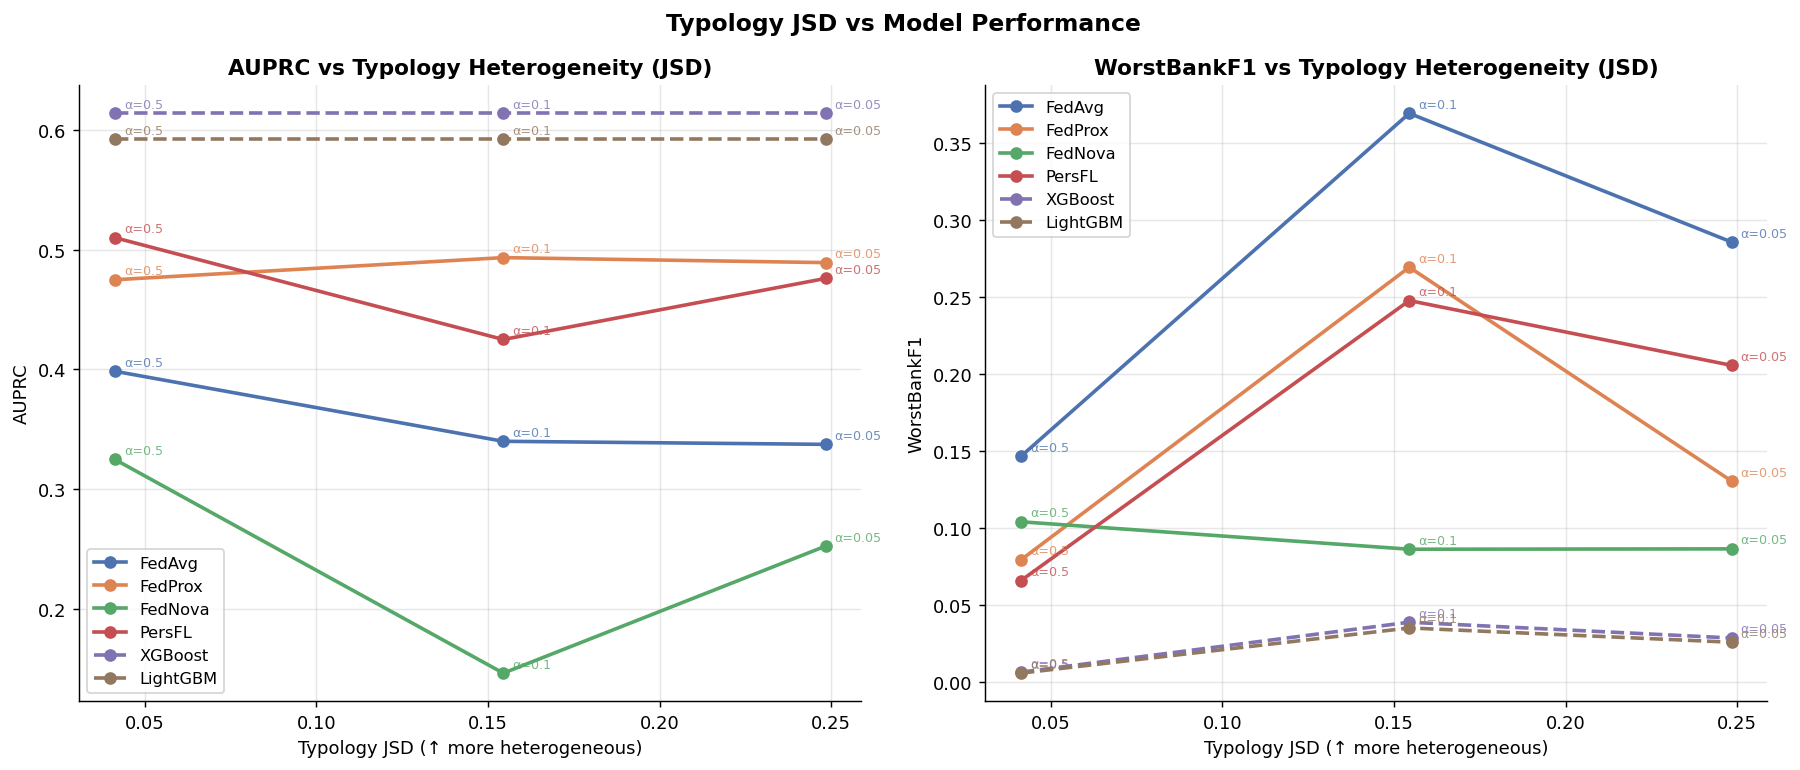

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Typology JSD vs Model Performance', fontsize=13, fontweight='bold')

for ax, metric in zip(axes, ['AUPRC', 'WorstBankF1']):
    for model in ALL_MODELS:
        xs = [jsd_cache[a] for a in CFG['alphas']]
        if metric == 'WorstBankF1':
            ys = [RESULTS[(a, model)]['fairness']['WorstBankF1'] for a in CFG['alphas']]
        else:
            ys = [RESULTS[(a, model)]['final_metrics'][metric] for a in CFG['alphas']]

        ls = '--' if model in TREE_MODELS else '-'
        ax.plot(xs, ys, marker='o', linewidth=2, linestyle=ls,
                label=model, color=PALETTE[model])
        # Annotate alpha values
        for x, y, a in zip(xs, ys, CFG['alphas']):
            ax.annotate(f'α={a}', (x, y), textcoords='offset points',
                        xytext=(5, 3), fontsize=7, color=PALETTE[model], alpha=0.8)

    ax.set_xlabel('Typology JSD (↑ more heterogeneous)')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} vs Typology Heterogeneity (JSD)', fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('plot_12_jsd_correlation.png', bbox_inches='tight', dpi=150)
plt.show()

### 8.13 — Per-Bank F1 Box / Swarm Plot (Client Fairness)

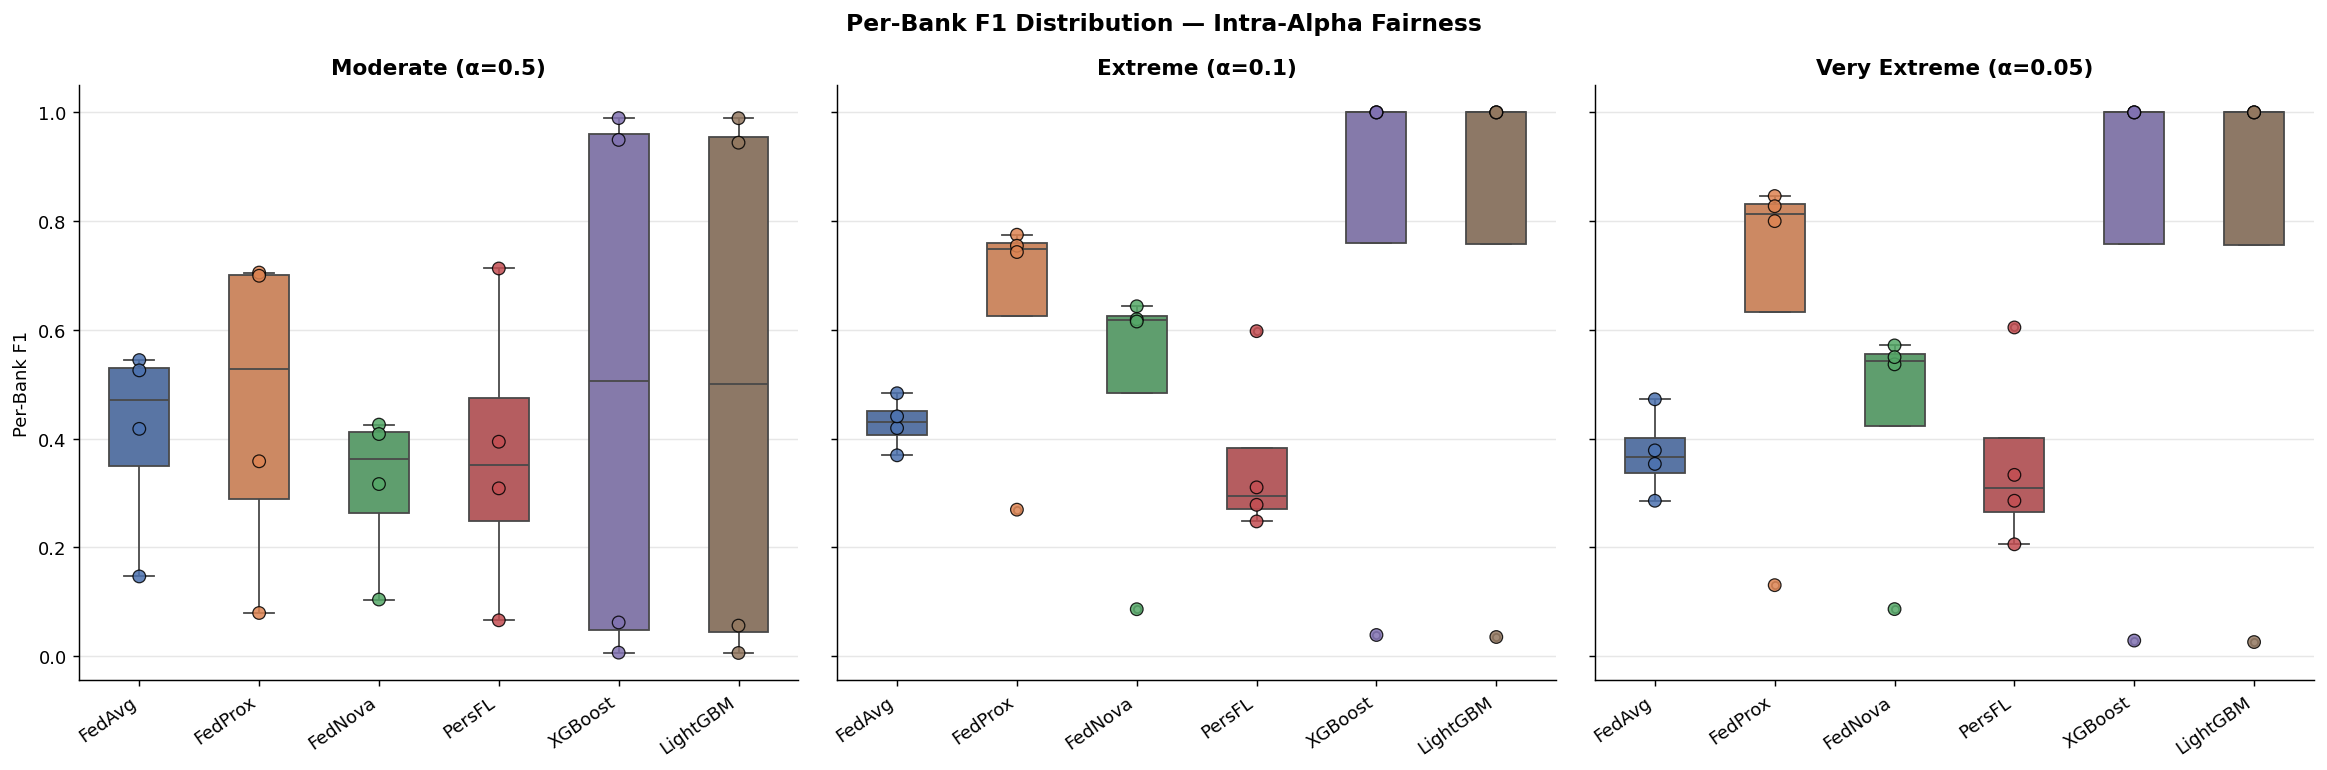

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('Per-Bank F1 Distribution — Intra-Alpha Fairness',
             fontsize=13, fontweight='bold')

for ax, alpha in zip(axes, CFG['alphas']):
    model_names_all, f1_vals_all = [], []
    for model in ALL_MODELS:
        pbf = RESULTS[(alpha, model)]['per_bank_f1']
        for f1_val in pbf:
            model_names_all.append(model)
            f1_vals_all.append(f1_val)

    df_fair = pd.DataFrame({'Model': model_names_all, 'F1': f1_vals_all})

    # Box
    sns.boxplot(
        data=df_fair, x='Model', y='F1', ax=ax,
        palette=PALETTE, order=ALL_MODELS,
        width=0.5, fliersize=4,
    )
    # Overlay individual bank points
    sns.stripplot(
        data=df_fair, x='Model', y='F1', ax=ax,
        palette=PALETTE, order=ALL_MODELS,
        size=7, jitter=False, dodge=False,
        edgecolor='black', linewidth=0.7, alpha=0.85,
    )

    ax.set_title(ALPHA_LABELS[alpha], fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Per-Bank F1')
    ax.set_xticklabels(ALL_MODELS, rotation=35, ha='right')

plt.tight_layout()
plt.savefig('plot_13_per_bank_f1.png', bbox_inches='tight', dpi=150)
plt.show()

## 9 — Statistical Summary & Key Findings

In [22]:
print('=' * 70)
print('  KEY FINDINGS SUMMARY')
print('=' * 70)

for alpha in CFG['alphas']:
    print(f'\n▶ {ALPHA_LABELS[alpha]}')

    # Best model by AUPRC
    best = max(ALL_MODELS, key=lambda m: RESULTS[(alpha, m)]['final_metrics']['AUPRC'])
    print(f'  Best AUPRC       : {best} = '
          f'{RESULTS[(alpha,best)]["final_metrics"]["AUPRC"]:.4f}')

    # Best FL fairness (lowest Client Equity)
    best_fair = min(FL_ALGOS,
                    key=lambda m: RESULTS[(alpha, m)]['fairness']['ClientEquity'])
    print(f'  Fairest FL algo  : {best_fair} — std(F1) = '
          f'{RESULTS[(alpha,best_fair)]["fairness"]["ClientEquity"]:.4f}')

    # Worst bank F1 across all FL models
    worst_wbf1  = min(FL_ALGOS, key=lambda m: RESULTS[(alpha,m)]['fairness']['WorstBankF1'])
    best_wbf1   = max(FL_ALGOS, key=lambda m: RESULTS[(alpha,m)]['fairness']['WorstBankF1'])
    print(f'  Best Worst-Bank  : {best_wbf1} = '
          f'{RESULTS[(alpha,best_wbf1)]["fairness"]["WorstBankF1"]:.4f}')

    # Positive collaboration gain?
    gainers = [m for m in FL_ALGOS
               if RESULTS[(alpha,m)]['fairness']['CollaborationGain'] > 0]
    print(f'  Positive Collab Gain: {", ".join(gainers) if gainers else "None"}')

    # Typology coverage champ
    cov_champ = max(ALL_MODELS,
                    key=lambda m: RESULTS[(alpha,m)]['final_metrics']['TypologyCoverage'])
    print(f'  Best Typo Coverage: {cov_champ} = '
          f'{RESULTS[(alpha,cov_champ)]["final_metrics"]["TypologyCoverage"]} / {len(TYPOLOGY_NAMES)}')

    # JSD
    print(f'  Typology JSD     : {jsd_cache[alpha]:.4f}')

print('\n' + '=' * 70)
print('  All plots saved: plot_01_convergence.png ... plot_13_per_bank_f1.png')
print('  Results CSV:     fl_fraud_results.csv')
print('=' * 70)

  KEY FINDINGS SUMMARY

▶ Moderate (α=0.5)
  Best AUPRC       : XGBoost = 0.6138
  Fairest FL algo  : FedNova — std(F1) = 0.1279
  Best Worst-Bank  : FedAvg = 0.1466
  Positive Collab Gain: FedAvg, FedProx, FedNova, PersFL
  Best Typo Coverage: FedAvg = 17 / 17
  Typology JSD     : 0.0413

▶ Extreme (α=0.1)
  Best AUPRC       : XGBoost = 0.6138
  Fairest FL algo  : FedAvg — std(F1) = 0.0411
  Best Worst-Bank  : FedAvg = 0.3693
  Positive Collab Gain: FedAvg, FedProx, FedNova, PersFL
  Best Typo Coverage: FedAvg = 17 / 17
  Typology JSD     : 0.1545

▶ Very Extreme (α=0.05)
  Best AUPRC       : XGBoost = 0.6138
  Fairest FL algo  : FedAvg — std(F1) = 0.0669
  Best Worst-Bank  : FedAvg = 0.2857
  Positive Collab Gain: FedAvg, FedProx, FedNova, PersFL
  Best Typo Coverage: FedAvg = 17 / 17
  Typology JSD     : 0.2483

  All plots saved: plot_01_convergence.png ... plot_13_per_bank_f1.png
  Results CSV:     fl_fraud_results.csv


## 10 — Export Results to JSON

In [23]:
# Serialise all metrics (excluding raw prob arrays) to JSON for reproducibility
export = {}
for (alpha, model), res in RESULTS.items():
    key = f'alpha={alpha}|{model}'
    export[key] = dict(
        alpha         = alpha,
        model         = model,
        round_auprc   = res['round_auprc'],
        final_metrics = {k: v for k, v in res['final_metrics'].items() if k != 'TypologyF1s'},
        typology_f1s  = res['final_metrics']['TypologyF1s'],
        fairness      = {k: v for k, v in res['fairness'].items()},
        typology_jsd  = res['jsd'],
        elapsed_s     = res['elapsed_s'],
    )

with open('fl_fraud_results.json', 'w') as f:
    json.dump(export, f, indent=2)

print('Results exported to fl_fraud_results.json')
print(f'Total experiment entries: {len(export)}')

Results exported to fl_fraud_results.json
Total experiment entries: 18
